# Weak-lensing galaxy shape catalogue validation

## Main notebook.

Version 10/05/2021

Includes
- PSF residuals
- PSF to galaxy shapes leakage
- Additive shear bias
- Convergence E- and B-modes
- Cluster lensing

In [17]:
import sys
import os
import numpy as np
from astropy.io import fits

import shapepipe
from shapepipe.utilities.canfar import download

In [18]:
# The following commands will be replaced by import instructions, once the sp_validation scripts are stable

sp_base = '{}/astro/repositories/github/sp_validation'.format(os.environ['HOME'])
sp_val = '{}/sp_validation'.format(sp_base)

for sc in ['survey', 'params', 'io', 'cat', 'basic']:
    script = os.path.join(sp_val, sc)
    %run $script

In [19]:
# Define function to read and run external notebook
import io
from nbformat import current

# See https://nbviewer.jupyter.org/gist/minrk/5491090/analysis.ipynb
def execute_notebook(nbfile):
    
    with io.open(nbfile) as f:
        nb = current.read(f, 'json')
    
    ip = get_ipython()
    
    for cell in nb.worksheets[0].cells:
        if cell.cell_type == 'code':
            ip.run_cell(cell.input)
        elif cell.cell_type == 'markdown':
            print('#'*80)
            print(cell.source)
        else:
            continue

# 1. - 4.: Set-up, load data, match stars for testing, select galaxies 

In [20]:
nb_path = "{}/notebooks/set_up_data_match_select.ipynb".format(sp_base)
execute_notebook(nb_path)

################################################################################
# Weak-lensing galaxy shape catalogue validation 1
Call from master notebook.

Contents
1. Set-up
2. Load data
3. Matching of stars
4. Select galaxies
################################################################################
## 2. Load data

### Load merged (final) galaxy catalogue
Column names:
('XWIN_WORLD', 'YWIN_WORLD', 'TILE_ID', 'FLAGS', 'IMAFLAGS_ISO', 'NGMIX_MCAL_FLAGS', 'NGMIX_ELL_PSFo_NOSHEAR', 'GALSIM_PSF_ELL_ORIGINAL_PSF', 'SPREAD_CLASS', 'SPREAD_MODEL', 'SPREADERR_MODEL', 'N_EPOCH', 'NGMIX_N_EPOCH', 'NGMIX_ELL_1M', 'NGMIX_ELL_1P', 'NGMIX_ELL_2M', 'NGMIX_ELL_2P', 'NGMIX_ELL_NOSHEAR', 'NGMIX_ELL_ERR_NOSHEAR', 'NGMIX_FLAGS_1M', 'NGMIX_FLAGS_1P', 'NGMIX_FLAGS_2M', 'NGMIX_FLAGS_2P', 'NGMIX_FLAGS_NOSHEAR', 'NGMIX_T_1M', 'NGMIX_T_1P', 'NGMIX_T_2M', 'NGMIX_T_2P', 'NGMIX_T_NOSHEAR', 'NGMIX_T_ERR_1M', 'NGMIX_T_ERR_1P', 'NGMIX_T_ERR_2M', 'NGMIX_T_ERR_2P', 'NGMIX_T_ERR_NOSHEAR', 'NGMIX_Tpsf_1M', 'N

## 5. Metacalibration

################################################################################
# Weak-lensing galaxy shape catalogue validation 1

## Global metacalibration

Call from master notebook, after steps 1-4 have been carried out by call
of `set_up_data_match_select.ipybn`.

Contents.

5. Metacalibration (global)
################################################################################
Reminder: metacal selection.

Masking : Flags == 0   &   $\frac{T_{\rm gal}}{T_{\rm psf}}$ > 0.5   &   SNR > 10   &   SNR < 500
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
################################################################################
Cross correlation
Final number of galaxies : 9006
Galaxy density : 10.01 gal/arcmin2


67

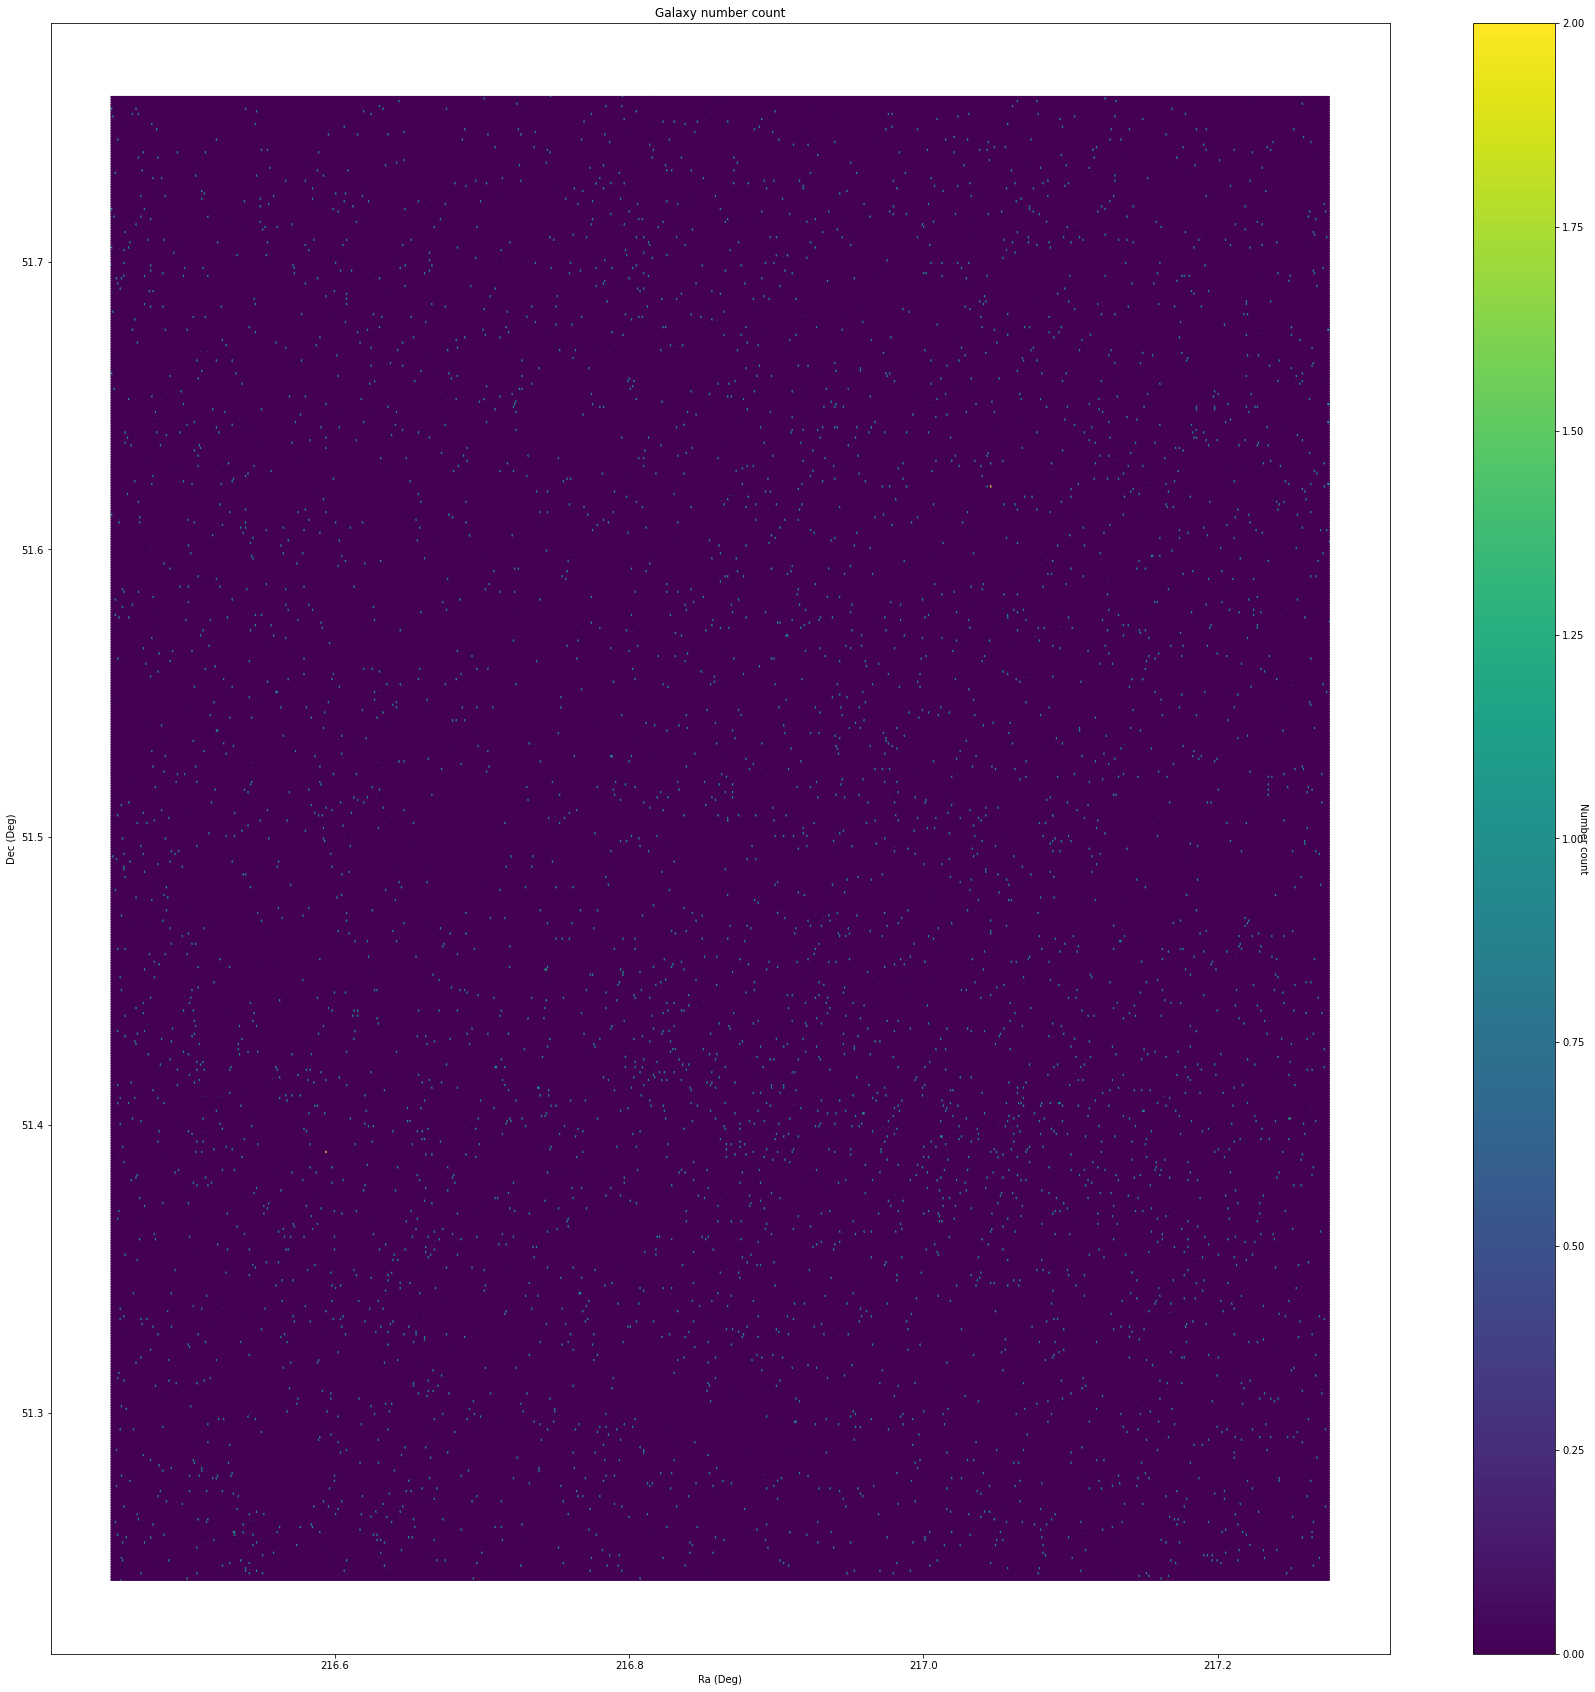

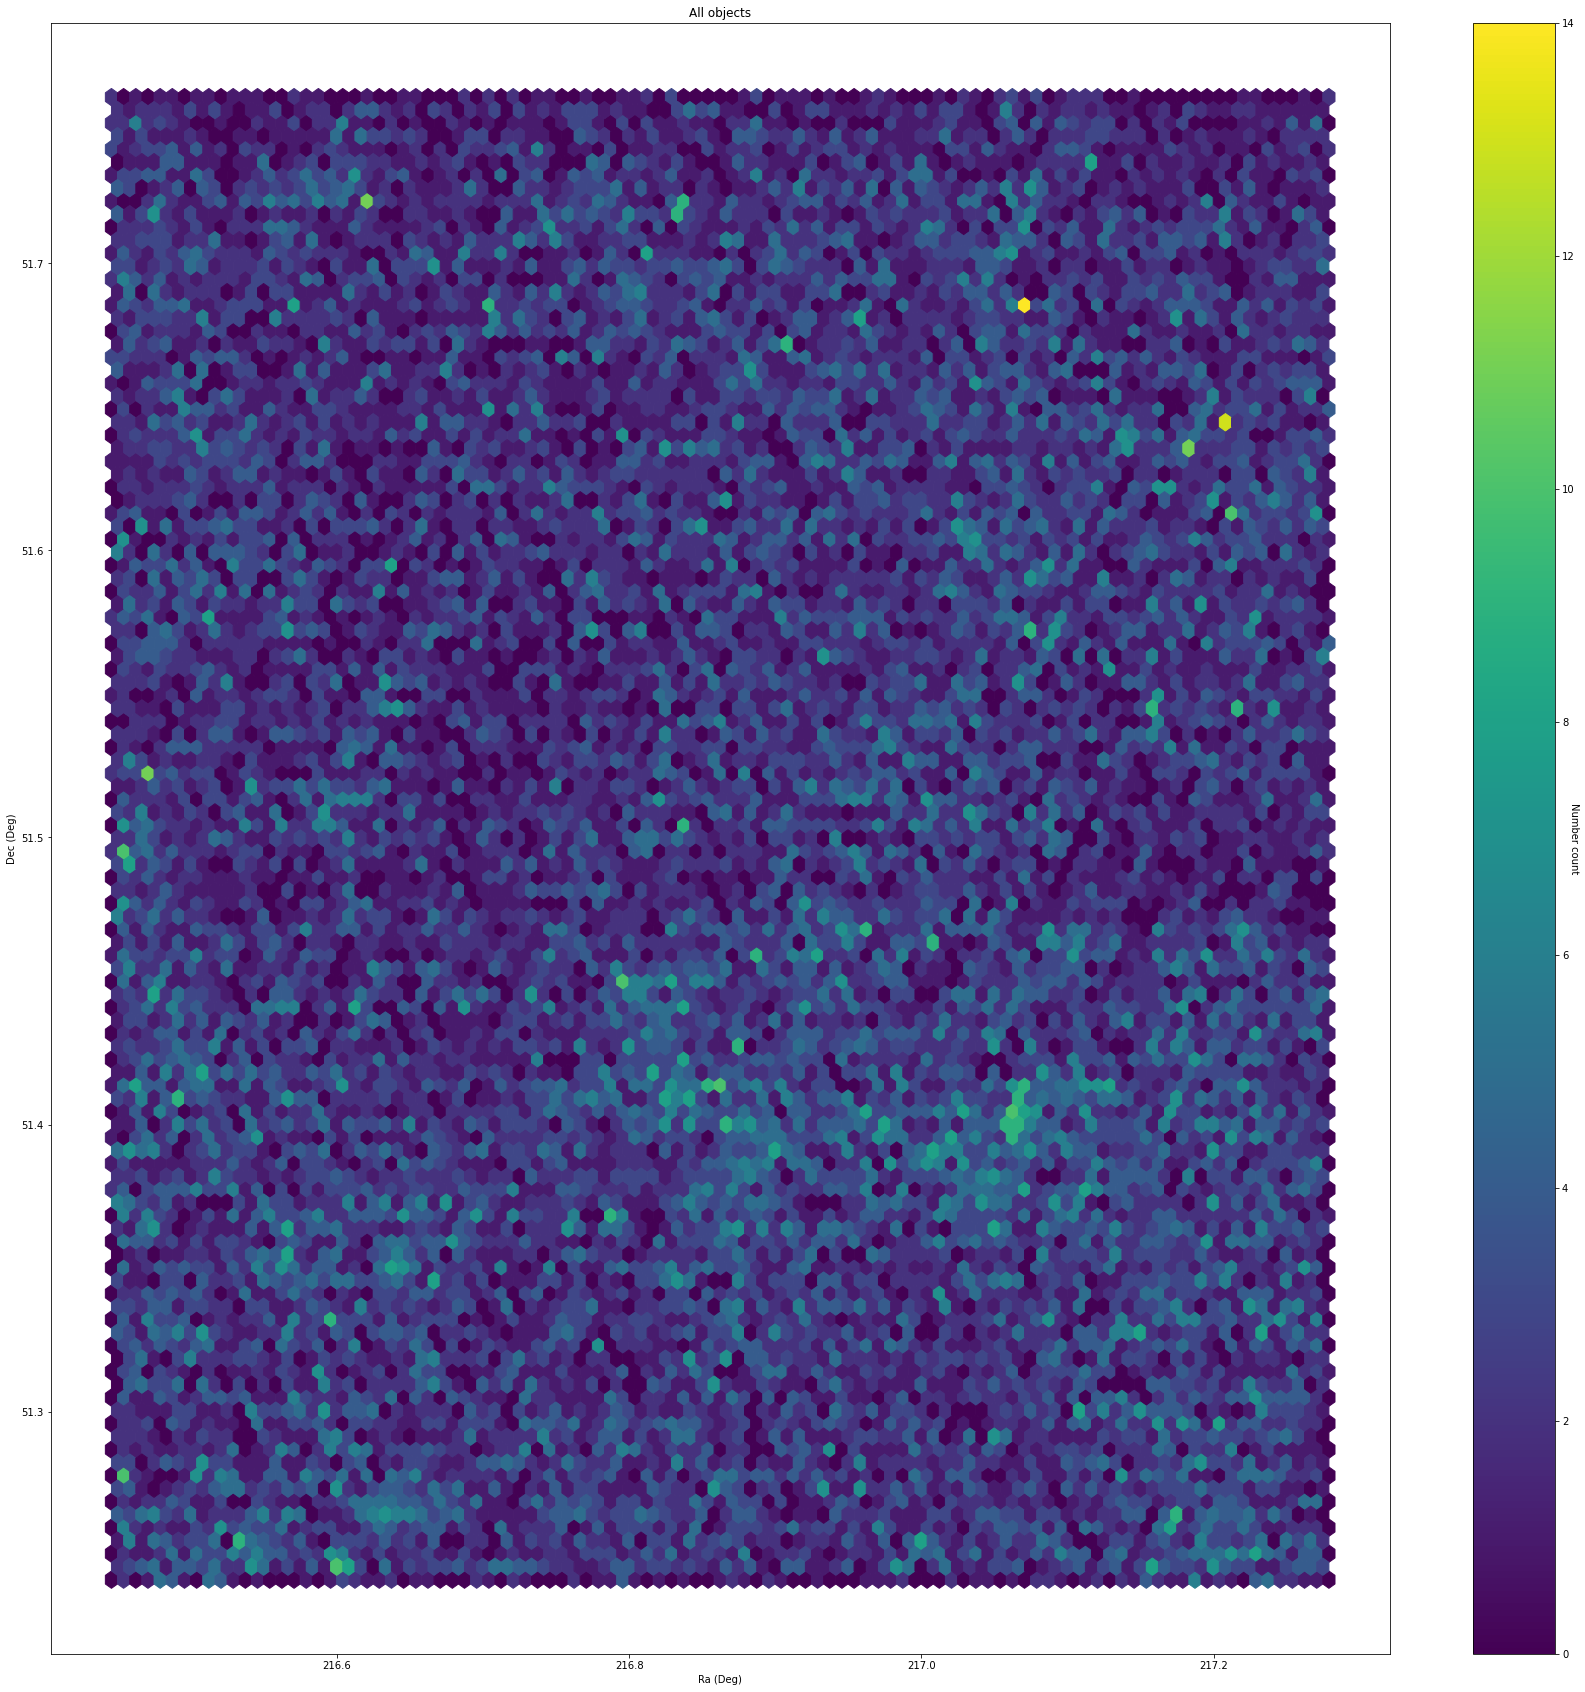

Text(0.5, 1.0, 'SNR cut')

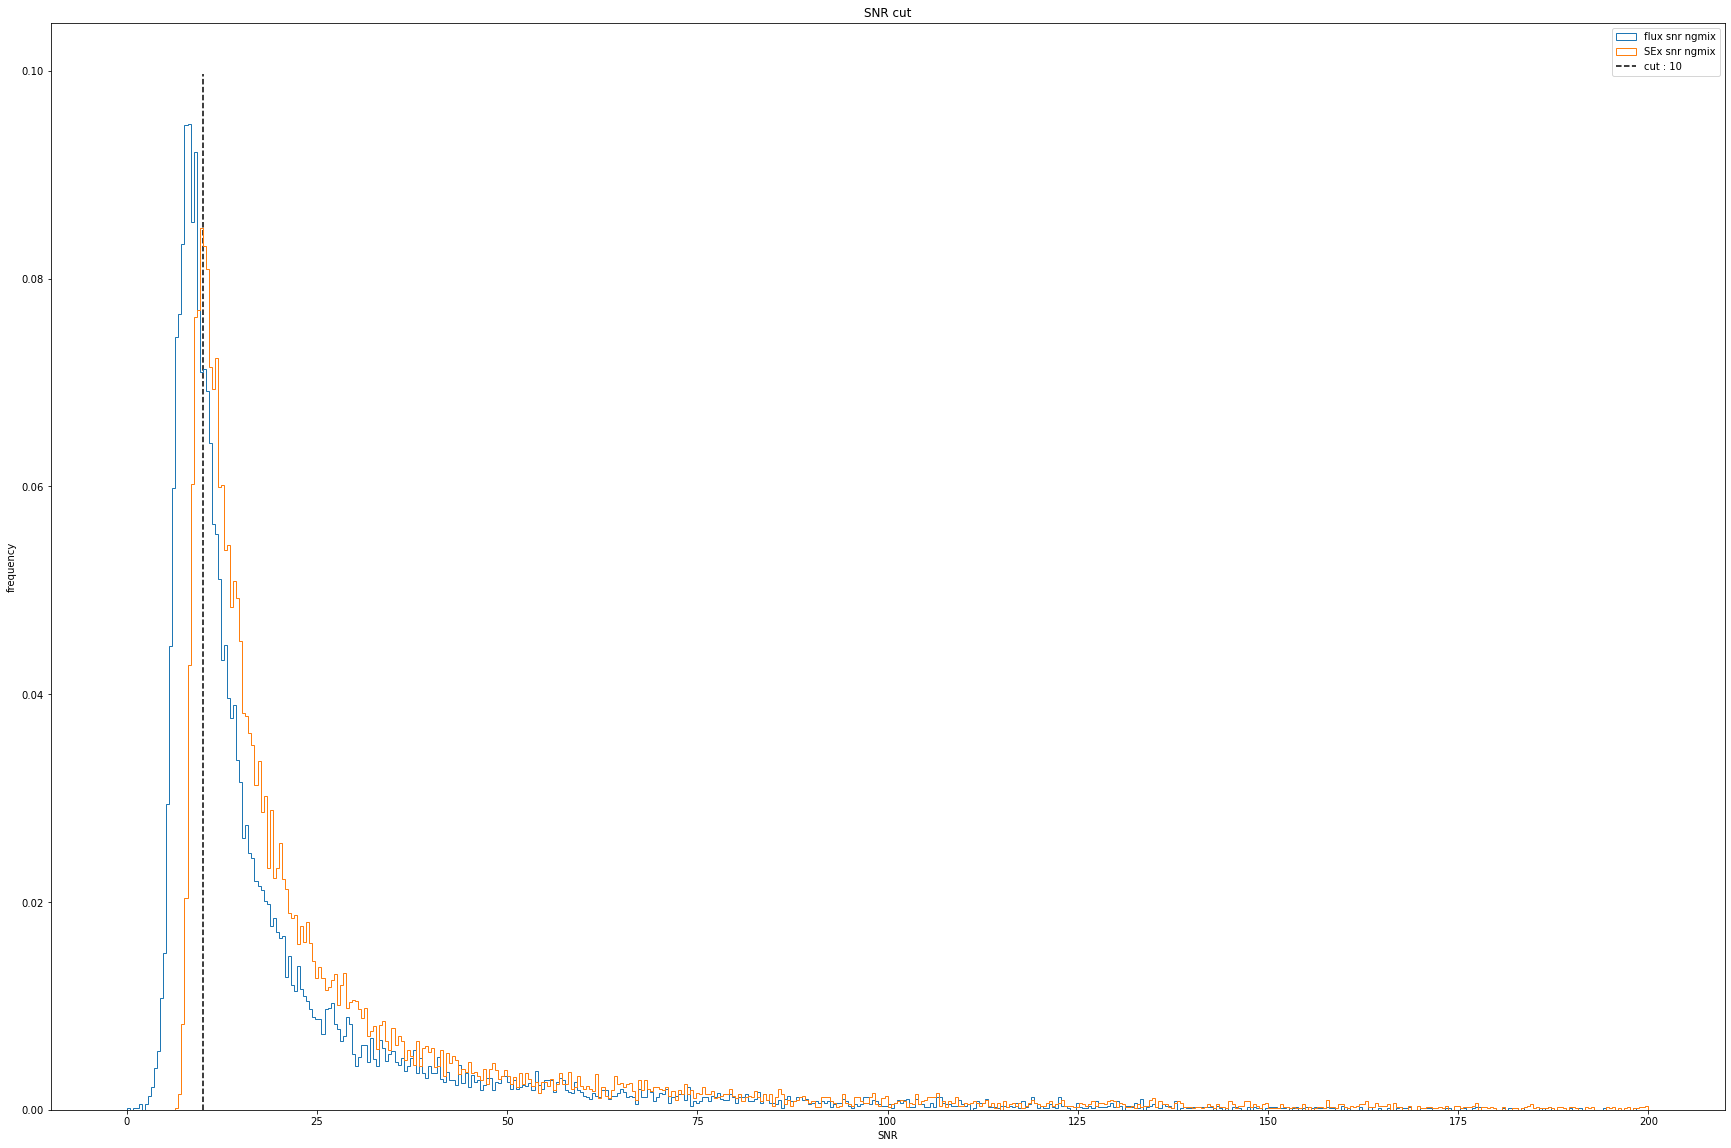

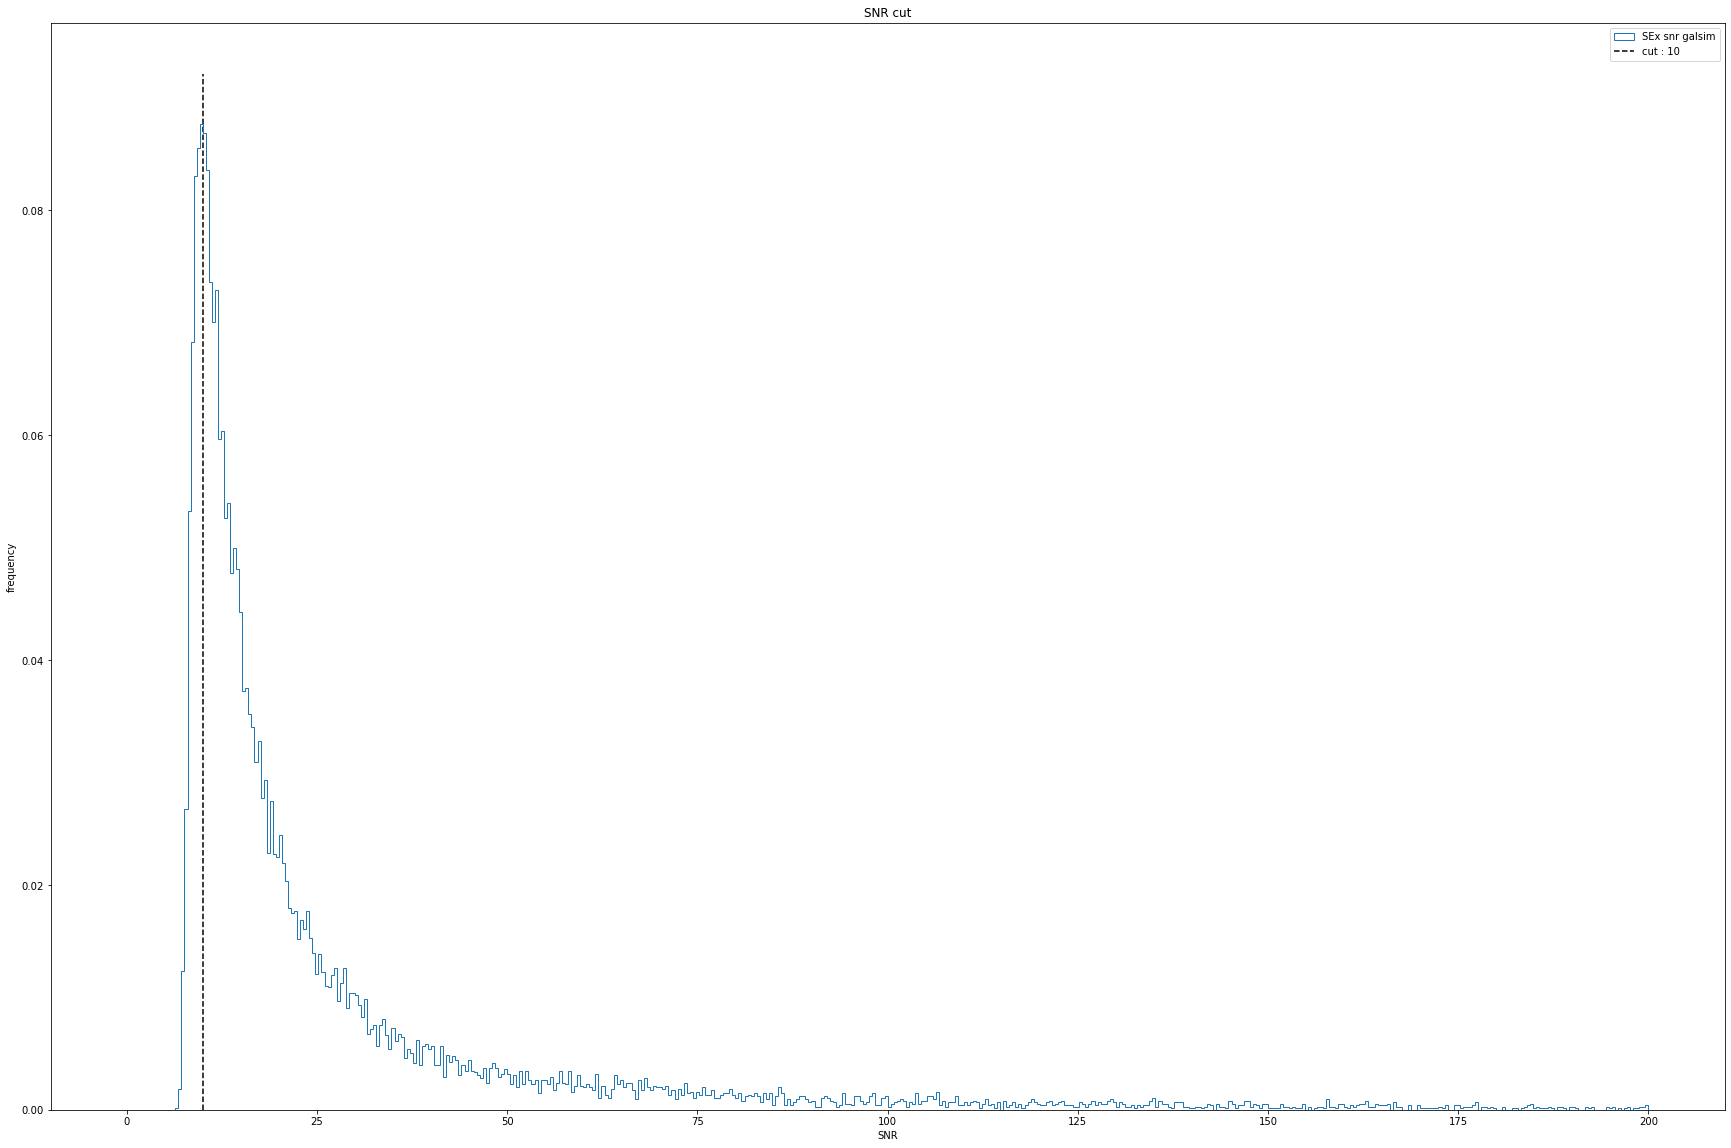

Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Final number of galaxies : 2076
Galaxy density : 0.01 gal/arcmin2


66

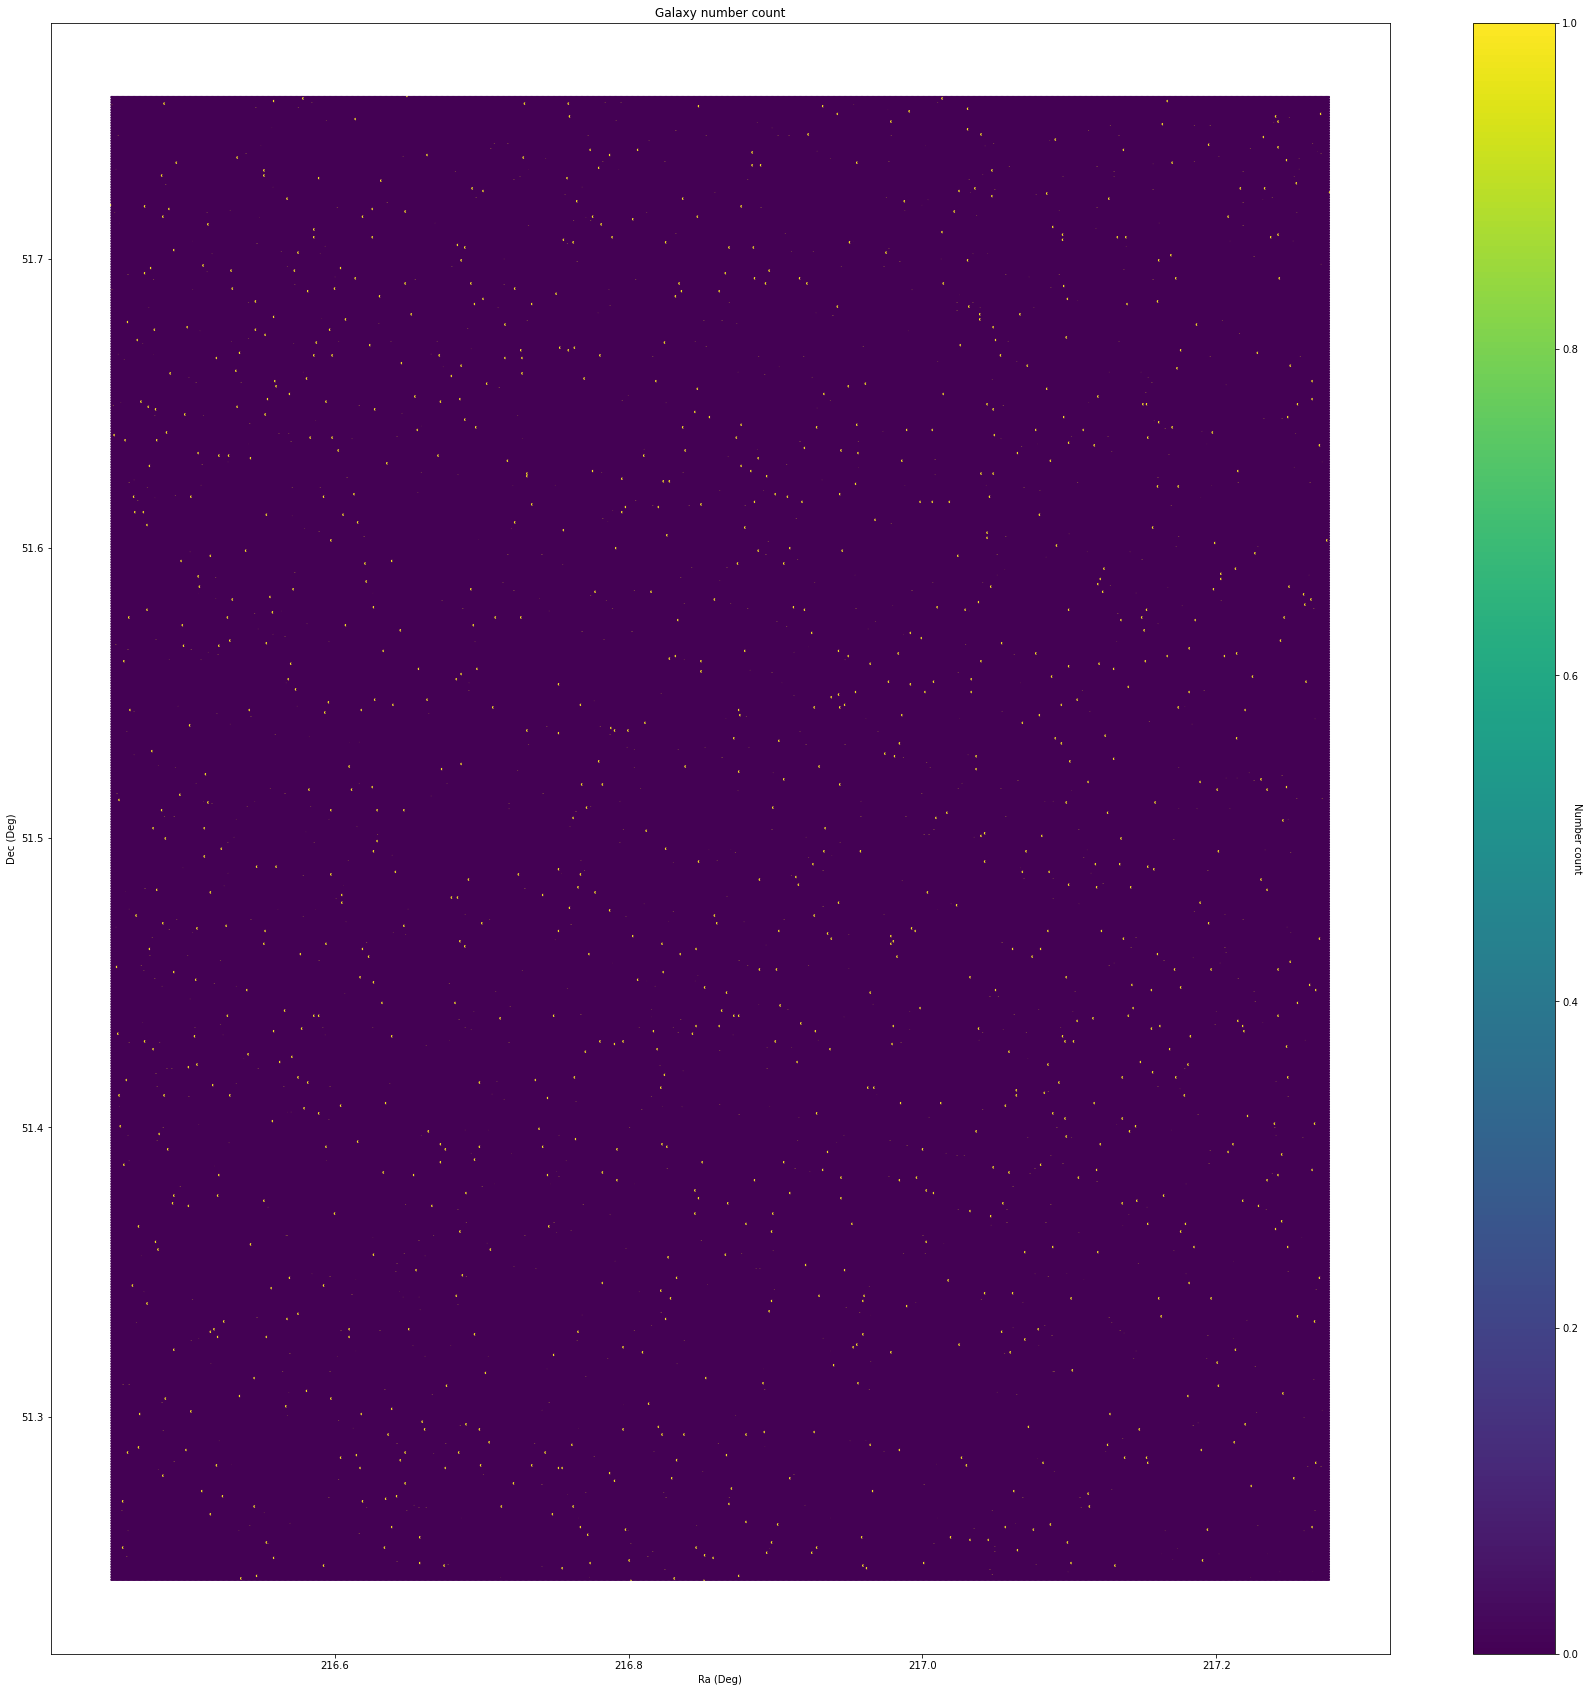

In [21]:
cal_spatial = 'global'
nb_path = "{}/notebooks/metacal_{}.ipynb".format(sp_base, cal_spatial)
execute_notebook(nb_path)

### Compile metacal for stars   
Masking : Flags == 0   &   SNR > 10   &   SNR < 500

#### Ngmix

In [ ]:
star_metacal_ngmix = metacal(dd[ind_star], m_star_ngmix, masking_type='star')

In [ ]:
n_star = len(star_metacal_ngmix.ns['g1'][star_metacal_ngmix.mask_dict['ns']])
tot_area = area_deg*3600
d_star = n_star / tot_area
print("Final number of stars : {}\nStar density : {:.2f}    star/arcmin^2\n               {:.2f} star/deg^2".format(n_star, d_star, d_star*3600))
dummy = stats_file.write("Final number of stars : {}\nStar density : {:.2f}    star/arcmin^2\n               {:.2f} star/deg^2\n".format(n_star, d_star, d_star*3600))

#### Galsim

In [ ]:
star_metacal_galsim = metacal(dd[ind_star], m_star_galsim, masking_type='star')

In [ ]:
n_star = len(star_metacal_galsim.ns['g1'][star_metacal_galsim.mask_dict['ns']])
tot_area = area_deg*3600
d_star = n_star / tot_area
print("Final number of stars : {}\nStar density : {:.2f}    star/arcmin^2\n               {:.2f} star/deg^2".format(n_star, d_star, d_star*3600))
stat_file.write("Final number of stars : {}\nStar density : {:.2f}    star/arcmin^2\n               {:.2f} star/deg^2\n".format(n_star, d_star, d_star*3600))

In [ ]:
plt.figure(figsize=(30,20))
plt.hist(gal_metacal_ngmix.R_shear[0,0], 500, range=(-3,3), histtype='step', density=True, linestyle="-", linewidth=2, color='blue', label='$R11_{gal}$')
plt.hist(gal_metacal_ngmix.R_shear[1,1], 500, range=(-3,3), histtype='step', density=True, linestyle="-", linewidth=2, color='red', label='$R22_{gal}$')
plt.hist(star_metacal_ngmix.R_shear[0,0,:], 500, histtype='step', range=(-3,3), density=True, linestyle=":", linewidth=2, color='blue', label='$R11_{star}$')
plt.hist(star_metacal_ngmix.R_shear[1,1,:], 500, histtype='step', range=(-3,3), density=True, linestyle=":", linewidth=2, color='red', label='$R22_{star}$')
plt.legend()
plt.xlabel('$R_{ii}$')
plt.ylabel('Nb')
plt.title('Response matrix ngmix')
plt.savefig(plot_dir + 'response_matrix_ngmix.png')

In [ ]:
plt.figure(figsize=(30,20))
plt.hist(gal_metacal_galsim.R_shear[0,0], 500, range=(-3,3), histtype='step', density=True, linestyle="-", linewidth=2, color='blue', label='$R11_{gal}$')
plt.hist(gal_metacal_galsim.R_shear[1,1], 500, range=(-3,3), histtype='step', density=True, linestyle="-", linewidth=2, color='red', label='$R22_{gal}$')
plt.hist(star_metacal_galsim.R_shear[0,0,:], 500, histtype='step', range=(-3,3), density=True, linestyle=":", linewidth=2, color='blue', label='$R11_{star}$')
plt.hist(star_metacal_galsim.R_shear[1,1,:], 500, histtype='step', range=(-3,3), density=True, linestyle=":", linewidth=2, color='red', label='$R22_{star}$')
plt.legend()
plt.xlabel('$R_{ii}$')
plt.ylabel('Nb')
plt.title('Response matrix galsim')
plt.savefig(plot_dir + 'response_matrix_galsim.png')

### Galaxy response

#### Ngmix

In [ ]:
print('Galaxy total response matrix ngmix : [[{:.2f}    {:.2e}]\n                                [{:.2e}    {:.2f}]]'.format(gal_metacal_ngmix.R[0,0], gal_metacal_ngmix.R[0,1], gal_metacal_ngmix.R[1,0], gal_metacal_ngmix.R[1,1]))
dummy = stat_file.write('Galaxy total response matrix ngmix : [[{:.2f}    {:.2e}]\n                                [{:.2e}    {:.2f}]]\n'.format(gal_metacal_ngmix.R[0,0], gal_metacal_ngmix.R[0,1], gal_metacal_ngmix.R[1,0], gal_metacal_ngmix.R[1,1]))

In [ ]:
print('Galaxy selection response matrix ngmix : [[{:.3f}    {:.2e}]\n                                    [{:.2e}    {:.3f}]]'.format(gal_metacal_ngmix.R_selection[0,0], gal_metacal_ngmix.R_selection[0,1], gal_metacal_ngmix.R_selection[1,0], gal_metacal_ngmix.R_selection[1,1]))
dummy = stat_file.write('Galaxy selection response matrix ngmix : [[{:.3f}    {:.2e}]\n                                    [{:.2e}    {:.3f}]]\n'.format(gal_metacal_ngmix.R_selection[0,0], gal_metacal_ngmix.R_selection[0,1], gal_metacal_ngmix.R_selection[1,0], gal_metacal_ngmix.R_selection[1,1]))

In [ ]:
R_shear = np.mean(gal_metacal_ngmix.R_shear, 2)
print(R_shear)
print(gal_metacal_ngmix.R_selection)
R_sum = R_shear + gal_metacal_ngmix.R_selection
print(R_sum)

In [ ]:
print(np.shape(gal_metacal_ngmix.R_selection))

#### Galsim

In [ ]:
print('Galaxy total response matrix galsim : [[{:.2f}    {:.2e}]\n                                [{:.2e}    {:.2f}]]'.format(gal_metacal_galsim.R[0,0], gal_metacal_galsim.R[0,1], gal_metacal_galsim.R[1,0], gal_metacal_galsim.R[1,1]))
stats_file.write('Galaxy total response matrix galsim : [[{:.2f}    {:.2e}]\n                                [{:.2e}    {:.2f}]]\n'.format(gal_metacal_galsim.R[0,0], gal_metacal_galsim.R[0,1], gal_metacal_galsim.R[1,0], gal_metacal_galsim.R[1,1]))

In [ ]:
print('Galaxy selection response matrix galsim : [[{:.3f}    {:.2e}]\n                                    [{:.2e}    {:.3f}]]'.format(gal_metacal_galsim.R_selection[0,0], gal_metacal_galsim.R_selection[0,1], gal_metacal_galsim.R_selection[1,0], gal_metacal_galsim.R_selection[1,1]))
stats_file.write('Galaxy selection response matrix galsim : [[{:.3f}    {:.2e}]\n                                    [{:.2e}    {:.3f}]]\n'.format(gal_metacal_galsim.R_selection[0,0], gal_metacal_galsim.R_selection[0,1], gal_metacal_galsim.R_selection[1,0], gal_metacal_galsim.R_selection[1,1]))

### Star response

In [ ]:
print('Star total response matrix ngmix : [[{:.2f}     {:.2e}]\n                              [{:.2e}    {:.2f}]]'.format(star_metacal_ngmix.R[0,0], star_metacal_ngmix.R[0,1], star_metacal_ngmix.R[1,0], star_metacal_ngmix.R[1,1]))
stat_file.write('Star total response matrix ngmix : [[{:.2f}     {:.2e}]\n                              [{:.2e}    {:.2f}]]\n'.format(star_metacal_ngmix.R[0,0], star_metacal_ngmix.R[0,1], star_metacal_ngmix.R[1,0], star_metacal_ngmix.R[1,1]))

In [ ]:
print('Star total response matrix galsim : [[{:.2f}     {:.2e}]\n                              [{:.2e}    {:.2f}]]'.format(star_metacal_galsim.R[0,0], star_metacal_galsim.R[0,1], star_metacal_galsim.R[1,0], star_metacal_galsim.R[1,1]))
stat_file.write('Star total response matrix galsim : [[{:.2f}     {:.2e}]\n                              [{:.2e}    {:.2f}]]\n'.format(star_metacal_galsim.R[0,0], star_metacal_galsim.R[0,1], star_metacal_galsim.R[1,0], star_metacal_galsim.R[1,1]))

In [ ]:
# The following creates an eror, star_response not found
#print('Star selection response matrix : [[{:.2e}    {:.2e}]\n                                  [{:.2e}    {:.2e}]]'.format(star_metacal.R_selection[0,0], star_metacal.R_selection[0,1], star_metacal.R_selection[1,0], star_metacal.R_selection[1,1]))
#stat_file.write('Star selection response matrix : [[{:.2e}    {:.2e}]\n                                  [{:.2e}    {:.2e}]]\n'.format(star_metacal.R_selection[0,0], star_metacal.R_selection[0,1], star_metacal.R_selection[1,0], star_metacal.R_selection[1,1]))

In [ ]:
plt.figure(figsize=(30,20))
plt.hist(g_corr_ngmix[0], 500, weights=w_ngmix, histtype='step', density=True, label="$e_{1}$")
plt.hist(g_corr_ngmix[1], 500, weights=w_ngmix, histtype='step', density=True, label="$e_{2}$")
plt.legend()
plt.xlabel('$e_{i}$')
plt.ylabel('Nb')
plt.title("$e_{\\rm gal}$ distribution ngmix")
plt.savefig(plot_dir + 'e_gal_distribution_ngmix.png')

In [ ]:
plt.figure(figsize=(30,20))
plt.hist(g_corr_galsim[0], 500, weights=w_galsim, histtype='step', density=True, label="$e_{1}$")
plt.hist(g_corr_galsim[1], 500, weights=w_galsim, histtype='step', density=True, label="$e_{2}$")
plt.legend()
plt.xlabel('$e_{i}$')
plt.ylabel('Nb')
plt.title("$e_{\\rm gal}$ distribution galsim")
plt.savefig(plot_dir + 'e_gal_distribution.png')

In [ ]:
plt.figure(figsize=(30,20))
plt.hist(star_metacal_ngmix.ns['g1'][star_metacal_ngmix.mask_dict['ns']], 500, weights=star_metacal_ngmix.ns['w'][star_metacal_ngmix.mask_dict['ns']], histtype='step', density=True, label="$e_{1}$")
plt.hist(star_metacal_ngmix.ns['g2'][star_metacal_ngmix.mask_dict['ns']], 500, weights=star_metacal_ngmix.ns['w'][star_metacal_ngmix.mask_dict['ns']], histtype='step', density=True, label="$e_{2}$")
plt.legend()
plt.xlabel('$e_{i}$')
plt.ylabel('Nb')
plt.title("$e_{star}$ distribution")
plt.savefig(plot_dir + 'e_star_distribution.png')

In [ ]:
plt.figure(figsize=(30,20))
plt.hist(star_metacal_galsim.ns['g1'][star_metacal_galsim.mask_dict['ns']], 500, weights=star_metacal_galsim.ns['w'][star_metacal_galsim.mask_dict['ns']], histtype='step', density=True, label="$e_{1}$")
plt.hist(star_metacal_galsim.ns['g2'][star_metacal_galsim.mask_dict['ns']], 500, weights=star_metacal_galsim.ns['w'][star_metacal_galsim.mask_dict['ns']], histtype='step', density=True, label="$e_{2}$")
plt.legend()
plt.xlabel('$e_{i}$')
plt.ylabel('Nb')
plt.title("$e_{star}$ distribution")
plt.savefig(plot_dir + 'e_star_distribution_galsim.png')

In [ ]:
plt.figure(figsize=(30,20))
plt.hist(dd['MAG_AUTO'][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']], 500)
plt.xlabel('Mag')
plt.ylabel('Nb')
plt.title('Magnitude distribution')
plt.savefig(plot_dir + 'gal_mag_distribution_ngmix.png')

In [ ]:
plt.figure(figsize=(30,20))
plt.hist(dd['MAG_AUTO'][m_gal_galsim][gal_metacal_galsim.mask_dict['ns']], 500)
plt.xlabel('Mag')
plt.ylabel('Nb')
plt.title('Magnitude distribution')
plt.savefig(plot_dir + 'gal_mag_distribution_galsim.png')

In [ ]:
plt.figure(figsize=(30,20))
plt.hist(dd['MAG_AUTO'][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']], 500, weights=w_ngmix, histtype='step', density=True)
plt.hist(dd['MAG_AUTO'][m_gal_galsim][gal_metacal_galsim.mask_dict['ns']], 500, histtype='step', density=True)
plt.xlabel('Mag')
plt.ylabel('Nb')
plt.title('Magnitude distribution')
plt.savefig(plot_dir + 'gal_mag_distribution_both.png')

## Additive bias

#### Ngmix

In [ ]:
c1_ngmix, err_c1_ngmix = jackknif_weighted_average(g_corr_ngmix[0], w_ngmix, remove_size=0.05, n_realization=500)
print('Additive bias c1 : {:.3e} +/- {:.3e}'.format(c1_ngmix, err_c1_ngmix))
stat_file.write('Additive bias c1 : {:.3e} +/- {:.3e}\n'.format(c1_ngmix, err_c1_ngmix))

In [ ]:
c2_ngmix, err_c2_ngmix = jackknif_weighted_average(g_corr_ngmix[1], w_ngmix, remove_size=0.05, n_realization=500)
print('Additive bias c2 : {:.3e} +/- {:.3e}'.format(c2_ngmix, err_c2_ngmix))
stat_file.write('Additive bias c2 : {:.3e} +/- {:.3e}\n'.format(c2_ngmix, err_c2_ngmix))

#### Galsim

In [ ]:
c1_galsim, err_c1_galsim = jackknif_weighted_average(g_corr_galsim[0], np.ones_like(w_galsim), remove_size=0.05, n_realization=500)
print('Additive bias c1 : {:.3e} +/- {:.3e}'.format(c1_galsim, err_c1_galsim))
stat_file.write('Additive bias c1 : {:.3e} +/- {:.3e}\n'.format(c1_galsim, err_c1_galsim))

In [ ]:
c2_galsim, err_c2_galsim = jackknif_weighted_average(g_corr_galsim[1], np.ones_like(w_galsim), remove_size=0.05, n_realization=500)
print('Additive bias c2 : {:.3e} +/- {:.3e}'.format(c2_galsim, err_c2_galsim))
stat_file.write('Additive bias c2 : {:.3e} +/- {:.3e}\n'.format(c2_galsim, err_c2_galsim))

In [ ]:
sig_eps = np.sqrt(np.var(g_corr_ngmix[0]) + np.var(g_corr_ngmix[1]))
print('Ellipticity dispersion (complex; mean per component): {:.3f}; {:.3f}'.format(sig_eps, sig_eps /  np.sqrt(2)))

## PSF leakage

### Binning leakage

Use PSF ellipticity at galaxy positions.

#### Ngmix

In [ ]:
psf_e_corr(g_corr_ngmix[0]-c1_ngmix, 
           g_corr_ngmix[1]-c2_ngmix,
           dd['NGMIX_ELL_PSFo_NOSHEAR'][:,0][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']], 
           dd['NGMIX_ELL_PSFo_NOSHEAR'][:,1][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']], 
           dd['NGMIX_T_PSFo_NOSHEAR'][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']]/1.17741*2.355, 
           weights=w_ngmix, 
           n_bin=30,
           save_plot=True,
           plot_dir=plot_dir + '/psf_leak_ngmix/')

In [ ]:
psf_e_corr(g_corr_galsim[0]-c1_galsim, 
           g_corr_galsim[1]-c2_galsim,
           dd['GALSIM_PSF_ELL_ORIGINAL_PSF'][:,0][m_gal_galsim][gal_metacal_galsim.mask_dict['ns']], 
           dd['GALSIM_PSF_ELL_ORIGINAL_PSF'][:,1][m_gal_galsim][gal_metacal_galsim.mask_dict['ns']], 
           dd['GALSIM_PSF_SIGMA_ORIGINAL_PSF'][m_gal_galsim][gal_metacal_galsim.mask_dict['ns']]*2.355*0.187, 
           weights=np.ones_like(w_galsim), 
           n_bin=30,
           save_plot=True,
           plot_dir=plot_dir + '/psf_leak_galsim/')

### Alpha leakage

Use PSF ellipticity at star positions.

Equation alpha leakage :
$
    \alpha = \frac{\xi_{+}^{gp} - \langle e_{gal} \rangle^{*} \langle e_{PSF} \rangle}{\xi_{+}^{pp} - |\langle e_{PSF} \rangle|^{2}}
$    
With $g$: galaxy and $p$: PSF.

#### Ngmix

In [ ]:
r_corr_gp_ngmix = xi_star_gal_tc(ra_ngmix, dec_ngmix, g_corr_ngmix[0]-c1_ngmix, g_corr_ngmix[1]-c2_ngmix, w_ngmix, ra_star_ngmix, dec_star_ngmix, g_star_psf_ngmix[0], g_star_psf_ngmix[1])
r_corr_pp_ngmix = xi_star_gal_tc(ra_star_ngmix, dec_star_ngmix, g_star_psf_ngmix[0], g_star_psf_ngmix[1], np.ones_like(g_star_psf_ngmix[0]), ra_star_ngmix, dec_star_ngmix, g_star_psf_ngmix[0], g_star_psf_ngmix[1])

In [ ]:
complex_gal_ngmix = np.average(g_corr_ngmix[0]-c1_ngmix, weights=w_ngmix) + np.average(g_corr_ngmix[1]-c2_ngmix, weights=w_ngmix)*1j
complex_psf_ngmix = np.mean(g_star_psf_ngmix[0]) + np.mean(g_star_psf_ngmix[1])*1j

In [ ]:
alpha_leak_ngmix = (r_corr_gp_ngmix.xip - np.real(np.conj(complex_gal_ngmix)*complex_psf_ngmix))/(r_corr_pp_ngmix.xip - np.abs(complex_psf_ngmix)**2.)

In [ ]:
sig_alpha_leak_ngmix = np.abs(alpha_leak_ngmix)*np.sqrt((np.sqrt(r_corr_gp_ngmix.varxip)/r_corr_gp_ngmix.xip)**2. + (np.sqrt(r_corr_pp_ngmix.varxip)/r_corr_pp_ngmix.xip)**2.)

In [ ]:
alpha_leak_mean_ngmix = np.average(alpha_leak_ngmix, weights=1/sig_alpha_leak_ngmix**2.)
print('All sales weitghed average alpha : {}'.format(alpha_leak_mean_ngmix))
stat_file.write('All scales weitghed average alpha : {}\n'.format(alpha_leak_mean_ngmix))

In [ ]:
mpl.rcParams['lines.linewidth'] = 3
mpl.rcParams['lines.markersize'] = 10
mpl.rcParams['font.size'] = 35
mpl.rcParams['xtick.minor.size'] = 7
mpl.rcParams['ytick.minor.size'] = 7
mpl.rcParams['xtick.major.size'] = 10
mpl.rcParams['ytick.major.size'] = 10
mpl.rcParams['xtick.major.width'] = 3
mpl.rcParams['ytick.major.width'] = 3
mpl.rcParams['boxplot.boxprops.linewidth'] = 2.
mpl.rcParams['boxplot.medianprops.linewidth'] = 2.
mpl.rcParams['boxplot.flierprops.markersize'] = 12
mpl.rcParams['boxplot.whiskerprops.linewidth'] = 2.
mpl.rcParams['boxplot.capprops.linewidth'] = 2.


mpl.rcParams['axes.xmargin'] = mpl.rcParamsDefault['axes.xmargin']

plt.figure(figsize=(30,20))

plt.errorbar(r_corr_gp_ngmix.meanr, alpha_leak_ngmix, yerr=sig_alpha_leak_ngmix, label=r'$\alpha$')
plt.hlines(y=0, xmin=plt.xlim()[0], xmax=plt.xlim()[1], linestyles='dashed')

plt.xscale('log')
#plt.yscale('log')
plt.xlim(plt.xlim()[0]+0.5,plt.xlim()[1]-30)
#plt.ylim(-0.5,0.5)
plt.xticks([2, 10, 200], labels=['2', '10', '200'])
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\alpha$')
#plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.legend()
plt.savefig(plot_dir + 'alpha_leakage_ngmix.png')

## $\xi^{sys}$

Use PSF ellipticity at star positions.

Equation alpha leakage :
$
\xi^{sys} = \frac{\xi_{\pm}^{gp^{2}}}{\xi_{\pm}^{pp}}
$    
With $g$: galaxy and $p$: PSF.

In [ ]:
C_sys_p_ngmix = r_corr_gp_ngmix.xip**2/r_corr_pp_ngmix.xip
C_sys_m_ngmix = r_corr_gp_ngmix.xim**2/r_corr_pp_ngmix.xim
#C_sys_var = np.sqrt(r_corr_gp.varxi**2./r_corr_pp.varxi)
C_sys_std_p_ngmix = np.abs(C_sys_p_ngmix) * np.sqrt((((2*r_corr_gp_ngmix.xip**2.*np.sqrt(r_corr_gp_ngmix.varxip))/r_corr_gp_ngmix.xip)/r_corr_gp_ngmix.xip**2.)**2. + (np.sqrt(r_corr_pp_ngmix.varxip)/r_corr_pp_ngmix.xip)**2.)
C_sys_std_m_ngmix = np.abs(C_sys_m_ngmix) * np.sqrt((((2*r_corr_gp_ngmix.xim**2.*np.sqrt(r_corr_gp_ngmix.varxim))/r_corr_gp_ngmix.xim)/r_corr_gp_ngmix.xim**2.)**2. + (np.sqrt(r_corr_pp_ngmix.varxim)/r_corr_pp_ngmix.xim)**2.)

## Redshift distribution

In [ ]:
nz_base = 'nz.CFHTLenSmatched.W3'
nz_ext = 'txt'
nz_date = '202012'
nz_version = 'v1'
nz_name = '{}_{}_{}.{}'.format(nz_base, nz_date, nz_version, nz_ext)
source = 'vos:cfis/cosmostat/cosmology/redshifts/{}'.format(nz_name)

download(source, nz_name, verbose=True)

In [ ]:
z, nz = np.loadtxt(nz_name, unpack=True)

#theta = np.logspace(np.log10(2), np.log10(2e2), 20)

Om = 0.3153
sig8 = 0.8111
ns = 0.9649
Ob = 0.0493
h = 0.6736
xi_p_planck, xi_m_planck = get_theo_xi(r_corr_gp_ngmix.meanr, z, nz, Omega_m=Om, h=h, Omega_b=Ob, sig8=sig8, ns=ns)

In [ ]:
#mpl.rcParams['lines.linewidth'] = 3
#mpl.rcParams['lines.markersize'] = 10
#mpl.rcParams['font.size'] = 35
#mpl.rcParams['xtick.minor.size'] = 7
#mpl.rcParams['ytick.minor.size'] = 7
#mpl.rcParams['xtick.major.size'] = 10
#mpl.rcParams['ytick.major.size'] = 10
#mpl.rcParams['xtick.major.width'] = 3
#mpl.rcParams['ytick.major.width'] = 3
#mpl.rcParams['boxplot.boxprops.linewidth'] = 2.
#mpl.rcParams['boxplot.medianprops.linewidth'] = 2.
#mpl.rcParams['boxplot.flierprops.markersize'] = 12
#mpl.rcParams['boxplot.whiskerprops.linewidth'] = 2.
#mpl.rcParams['boxplot.capprops.linewidth'] = 2.
#mpl.rcParams['axes.xmargin'] = mpl.rcParamsDefault['axes.xmargin']

color = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.figure(figsize=(30,20))
plt.errorbar(r_corr_gp_ngmix.meanr, C_sys_p_ngmix, yerr=C_sys_std_p_ngmix, label=r'$\xi_{+}^{sys}$')
plt.plot(r_corr_gp_ngmix.meanr, xi_p_planck, ':', color=color[0], label=r'$\xi_{+}^{\Lambda\mathrm{CDM}}$')
plt.plot(r_corr_gp_ngmix.meanr, xi_m_planck, ':', color=color[1], label=r'$\xi_{-}^{\Lambda\mathrm{CDM}}$')

#ind_neg = np.where(C_sys_m <= 0)[0]
#ind_pos = np.where(C_sys_m > 0)[0]
#plt.errorbar(res.meanr[ind_neg]+0.05*res.meanr[ind_neg], np.abs(C_sys_m[ind_neg]), yerr=C_sys_std_m[ind_neg], linestyle='--', color=color[1], label=r'$\xi_{-}^{sys}$')
#plt.errorbar(res.meanr[[ind_neg[-1], ind_pos[0]]]+0.05*res.meanr[[ind_neg[-1], ind_pos[0]]], np.abs(C_sys_m[[ind_neg[-1], ind_pos[0]]]), yerr=C_sys_std_m[[ind_neg[-1], ind_pos[0]]], linestyle='--', color=color[1])
#plt.errorbar(res.meanr[ind_pos]+0.05*res.meanr[ind_pos], C_sys_m[ind_pos], yerr=C_sys_std_m[ind_pos], color=color[1], linestyle='-')
plt.errorbar(r_corr_gp_ngmix.meanr*(1.02), C_sys_m_ngmix, yerr=C_sys_std_m_ngmix, label=r'$\xi_{-}^{sys}$')

plt.xscale('log')
plt.yscale('log')
plt.xlim(plt.xlim()[0]+0.,plt.xlim()[1]-30)

plt.xticks([2, 10, 200], labels=['2', '10', '200'])
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\xi_{\pm}$')
#plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.gca().yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v,_: ("$10^{%d}$" % math.log(v,10)) ))
plt.legend()
plt.savefig(plot_dir + 'xi_sys_ngmix.png')

In [ ]:
#mpl.rcParams['lines.linewidth'] = 3
#mpl.rcParams['lines.markersize'] = 10
#mpl.rcParams['font.size'] = 35
#mpl.rcParams['xtick.minor.size'] = 7
#mpl.rcParams['ytick.minor.size'] = 7
#mpl.rcParams['xtick.major.size'] = 10
#mpl.rcParams['ytick.major.size'] = 10
#mpl.rcParams['xtick.major.width'] = 3
#mpl.rcParams['ytick.major.width'] = 3
#mpl.rcParams['boxplot.boxprops.linewidth'] = 2.
#mpl.rcParams['boxplot.medianprops.linewidth'] = 2.
#mpl.rcParams['boxplot.flierprops.markersize'] = 12
#mpl.rcParams['boxplot.whiskerprops.linewidth'] = 2.
#mpl.rcParams['boxplot.capprops.linewidth'] = 2.
#mpl.rcParams['axes.xmargin'] = mpl.rcParamsDefault['axes.xmargin']

color = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.figure(figsize=(30,20))
#plt.errorbar(r_corr_gp.meanr, C_sys_p, yerr=C_sys_std_p, label=r'$\xi_{+}^{sys}$')
#plt.plot(r_corr_gp.meanr, f_theo_p_p(r_corr_gp.meanr), ':', color=color[0], label=r'$\xi_{+}^{\Lambda\mathrm{CDM}}$')
#plt.plot(r_corr_gp.meanr, f_theo_m_p(r_corr_gp.meanr), ':', color=color[1], label=r'$\xi_{-}^{\Lambda\mathrm{CDM}}$')
plt.plot(r_corr_gp_ngmix.meanr, C_sys_p_ngmix/xi_p_planck, color=color[0], label=r'$\xi_{\pm}/\xi_{+}^{\Lambda\mathrm{CDM}}$')

#ind_neg = np.where(C_sys_m <= 0)[0]
#ind_pos = np.where(C_sys_m > 0)[0]
#plt.errorbar(res.meanr[ind_neg]+0.05*res.meanr[ind_neg], np.abs(C_sys_m[ind_neg]), yerr=C_sys_std_m[ind_neg], linestyle='--', color=color[1], label=r'$\xi_{-}^{sys}$')
#plt.errorbar(res.meanr[[ind_neg[-1], ind_pos[0]]]+0.05*res.meanr[[ind_neg[-1], ind_pos[0]]], np.abs(C_sys_m[[ind_neg[-1], ind_pos[0]]]), yerr=C_sys_std_m[[ind_neg[-1], ind_pos[0]]], linestyle='--', color=color[1])
#plt.errorbar(res.meanr[ind_pos]+0.05*res.meanr[ind_pos], C_sys_m[ind_pos], yerr=C_sys_std_m[ind_pos], color=color[1], linestyle='-')
#plt.errorbar(r_corr_gp.meanr*(1.02), C_sys_m, yerr=C_sys_std_m, label=r'$\xi_{-}^{sys}$')

plt.xscale('log')
#plt.yscale('log')
plt.xlim(plt.xlim()[0]+0.,plt.xlim()[1]-30)

plt.xticks([2, 10, 200], labels=['2', '10', '200'])
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\xi_{\pm}/\xi_{+}^{\Lambda\mathrm{CDM}}$')
#plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.gca().yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v,_: ("$10^{%d}$" % math.log(v,10)) ))
plt.legend()
plt.savefig(plot_dir + 'xi_sys_ratio_ngmix.png')

#### Galsim

In [ ]:
r_corr_gp_galsim = xi_star_gal_tc(ra_galsim, dec_galsim, g_corr_galsim[0]-c1_galsim, g_corr_galsim[1]-c2_galsim, np.ones_like(w_galsim), ra_star_galsim, dec_star_galsim, g_star_psf_galsim[0], g_star_psf_galsim[1])
r_corr_pp_galsim = xi_star_gal_tc(ra_star_galsim, dec_star_galsim, g_star_psf_galsim[0], g_star_psf_galsim[1], np.ones_like(g_star_psf_galsim[0]), ra_star_galsim, dec_star_galsim, g_star_psf_galsim[0], g_star_psf_galsim[1])

In [ ]:
complex_gal_galsim = np.average(g_corr_galsim[0]-c1_galsim, weights=np.ones_like(w_galsim)) + np.average(g_corr_galsim[1]-c2_galsim, weights=np.ones_like(w_galsim))*1j
complex_psf_galsim = np.mean(g_star_psf_galsim[0]) + np.mean(g_star_psf_galsim[1])*1j

In [ ]:
alpha_leak_galsim = (r_corr_gp_galsim.xip - np.real(np.conj(complex_gal_galsim)*complex_psf_galsim))/(r_corr_pp_galsim.xip - np.abs(complex_psf_galsim)**2.)

In [ ]:
sig_alpha_leak_galsim = np.abs(alpha_leak_galsim)*np.sqrt((np.sqrt(r_corr_gp_galsim.varxip)/r_corr_gp_galsim.xip)**2. + (np.sqrt(r_corr_pp_galsim.varxip)/r_corr_pp_galsim.xip)**2.)

In [ ]:
alpha_leak_mean_galsim = np.average(alpha_leak_galsim, weights=1/sig_alpha_leak_galsim**2.)
print('All sales weitghed average alpha : {}'.format(alpha_leak_mean_galsim))
stat_file.write('All sales weitghed average alpha : {}\n'.format(alpha_leak_mean_galsim))

In [ ]:
mpl.rcParams['lines.linewidth'] = 3
mpl.rcParams['lines.markersize'] = 10
mpl.rcParams['font.size'] = 35
mpl.rcParams['xtick.minor.size'] = 7
mpl.rcParams['ytick.minor.size'] = 7
mpl.rcParams['xtick.major.size'] = 10
mpl.rcParams['ytick.major.size'] = 10
mpl.rcParams['xtick.major.width'] = 3
mpl.rcParams['ytick.major.width'] = 3
mpl.rcParams['boxplot.boxprops.linewidth'] = 2.
mpl.rcParams['boxplot.medianprops.linewidth'] = 2.
mpl.rcParams['boxplot.flierprops.markersize'] = 12
mpl.rcParams['boxplot.whiskerprops.linewidth'] = 2.
mpl.rcParams['boxplot.capprops.linewidth'] = 2.


mpl.rcParams['axes.xmargin'] = mpl.rcParamsDefault['axes.xmargin']

plt.figure(figsize=(30,20))

plt.errorbar(r_corr_gp_galsim.meanr, alpha_leak_galsim, yerr=sig_alpha_leak_galsim, label=r'$\alpha$')
plt.hlines(y=0, xmin=plt.xlim()[0], xmax=plt.xlim()[1], linestyles='dashed')

plt.xscale('log')
#plt.yscale('log')
plt.xlim(plt.xlim()[0]+0.5,plt.xlim()[1]-30)
#plt.ylim(-0.5,0.5)
plt.xticks([2, 10, 200], labels=['2', '10', '200'])
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\alpha$')
#plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.legend()
plt.savefig(plot_dir + 'alpha_leakage_galsim.png')

In [ ]:
C_sys_p_galsim = r_corr_gp_galsim.xip**2/r_corr_pp_galsim.xip
C_sys_m_galsim = r_corr_gp_galsim.xim**2/r_corr_pp_galsim.xim
#C_sys_var = np.sqrt(r_corr_gp.varxi**2./r_corr_pp.varxi)
C_sys_std_p_galsim = np.abs(C_sys_p_galsim) * np.sqrt((((2*r_corr_gp_galsim.xip**2.*np.sqrt(r_corr_gp_galsim.varxip))/r_corr_gp_galsim.xip)/r_corr_gp_galsim.xip**2.)**2. + (np.sqrt(r_corr_pp_galsim.varxip)/r_corr_pp_galsim.xip)**2.)
C_sys_std_m_galsim = np.abs(C_sys_m_galsim) * np.sqrt((((2*r_corr_gp_galsim.xim**2.*np.sqrt(r_corr_gp_galsim.varxim))/r_corr_gp_galsim.xim)/r_corr_gp_galsim.xim**2.)**2. + (np.sqrt(r_corr_pp_galsim.varxim)/r_corr_pp_galsim.xim)**2.)

In [ ]:
#mpl.rcParams['lines.linewidth'] = 3
#mpl.rcParams['lines.markersize'] = 10
#mpl.rcParams['font.size'] = 35
#mpl.rcParams['xtick.minor.size'] = 7
#mpl.rcParams['ytick.minor.size'] = 7
#mpl.rcParams['xtick.major.size'] = 10
#mpl.rcParams['ytick.major.size'] = 10
#mpl.rcParams['xtick.major.width'] = 3
#mpl.rcParams['ytick.major.width'] = 3
#mpl.rcParams['boxplot.boxprops.linewidth'] = 2.
#mpl.rcParams['boxplot.medianprops.linewidth'] = 2.
#mpl.rcParams['boxplot.flierprops.markersize'] = 12
#mpl.rcParams['boxplot.whiskerprops.linewidth'] = 2.
#mpl.rcParams['boxplot.capprops.linewidth'] = 2.
#mpl.rcParams['axes.xmargin'] = mpl.rcParamsDefault['axes.xmargin']

color = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.figure(figsize=(30,20))
plt.errorbar(r_corr_gp_galsim.meanr, C_sys_p_galsim, yerr=C_sys_std_p_galsim, label=r'$\xi_{+}^{sys}$')
plt.plot(r_corr_gp_galsim.meanr, xi_p_planck, ':', color=color[0], label=r'$\xi_{+}^{\Lambda\mathrm{CDM}}$')
plt.plot(r_corr_gp_galsim.meanr, xi_m_planck, ':', color=color[1], label=r'$\xi_{-}^{\Lambda\mathrm{CDM}}$')

#ind_neg = np.where(C_sys_m <= 0)[0]
#ind_pos = np.where(C_sys_m > 0)[0]
#plt.errorbar(res.meanr[ind_neg]+0.05*res.meanr[ind_neg], np.abs(C_sys_m[ind_neg]), yerr=C_sys_std_m[ind_neg], linestyle='--', color=color[1], label=r'$\xi_{-}^{sys}$')
#plt.errorbar(res.meanr[[ind_neg[-1], ind_pos[0]]]+0.05*res.meanr[[ind_neg[-1], ind_pos[0]]], np.abs(C_sys_m[[ind_neg[-1], ind_pos[0]]]), yerr=C_sys_std_m[[ind_neg[-1], ind_pos[0]]], linestyle='--', color=color[1])
#plt.errorbar(res.meanr[ind_pos]+0.05*res.meanr[ind_pos], C_sys_m[ind_pos], yerr=C_sys_std_m[ind_pos], color=color[1], linestyle='-')
plt.errorbar(r_corr_gp_galsim.meanr*(1.02), C_sys_m_galsim, yerr=C_sys_std_m_galsim, label=r'$\xi_{-}^{sys}$')

plt.xscale('log')
plt.yscale('log')
plt.xlim(plt.xlim()[0]+0.,plt.xlim()[1]-30)

plt.xticks([2, 10, 200], labels=['2', '10', '200'])
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\xi_{\pm}$')
#plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.gca().yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v,_: ("$10^{%d}$" % math.log(v,10)) ))
plt.legend()
plt.savefig(plot_dir + 'xi_sys_galsim.png')

In [ ]:
#mpl.rcParams['lines.linewidth'] = 3
#mpl.rcParams['lines.markersize'] = 10
#mpl.rcParams['font.size'] = 35
#mpl.rcParams['xtick.minor.size'] = 7
#mpl.rcParams['ytick.minor.size'] = 7
#mpl.rcParams['xtick.major.size'] = 10
#mpl.rcParams['ytick.major.size'] = 10
#mpl.rcParams['xtick.major.width'] = 3
#mpl.rcParams['ytick.major.width'] = 3
#mpl.rcParams['boxplot.boxprops.linewidth'] = 2.
#mpl.rcParams['boxplot.medianprops.linewidth'] = 2.
#mpl.rcParams['boxplot.flierprops.markersize'] = 12
#mpl.rcParams['boxplot.whiskerprops.linewidth'] = 2.
#mpl.rcParams['boxplot.capprops.linewidth'] = 2.
#mpl.rcParams['axes.xmargin'] = mpl.rcParamsDefault['axes.xmargin']

color = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.figure(figsize=(30,20))
#plt.errorbar(r_corr_gp.meanr, C_sys_p, yerr=C_sys_std_p, label=r'$\xi_{+}^{sys}$')
#plt.plot(r_corr_gp.meanr, f_theo_p_p(r_corr_gp.meanr), ':', color=color[0], label=r'$\xi_{+}^{\Lambda\mathrm{CDM}}$')
#plt.plot(r_corr_gp.meanr, f_theo_m_p(r_corr_gp.meanr), ':', color=color[1], label=r'$\xi_{-}^{\Lambda\mathrm{CDM}}$')
plt.plot(r_corr_gp_galsim.meanr, C_sys_p_galsim/xi_p_planck, color=color[0], label=r'$\xi_{\pm}/\xi_{+}^{\Lambda\mathrm{CDM}}$')

#ind_neg = np.where(C_sys_m <= 0)[0]
#ind_pos = np.where(C_sys_m > 0)[0]
#plt.errorbar(res.meanr[ind_neg]+0.05*res.meanr[ind_neg], np.abs(C_sys_m[ind_neg]), yerr=C_sys_std_m[ind_neg], linestyle='--', color=color[1], label=r'$\xi_{-}^{sys}$')
#plt.errorbar(res.meanr[[ind_neg[-1], ind_pos[0]]]+0.05*res.meanr[[ind_neg[-1], ind_pos[0]]], np.abs(C_sys_m[[ind_neg[-1], ind_pos[0]]]), yerr=C_sys_std_m[[ind_neg[-1], ind_pos[0]]], linestyle='--', color=color[1])
#plt.errorbar(res.meanr[ind_pos]+0.05*res.meanr[ind_pos], C_sys_m[ind_pos], yerr=C_sys_std_m[ind_pos], color=color[1], linestyle='-')
#plt.errorbar(r_corr_gp.meanr*(1.02), C_sys_m, yerr=C_sys_std_m, label=r'$\xi_{-}^{sys}$')

plt.xscale('log')
#plt.yscale('log')
plt.xlim(plt.xlim()[0]+0.,plt.xlim()[1]-30)

plt.xticks([2, 10, 200], labels=['2', '10', '200'])
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\xi_{\pm}/\xi_{+}^{\Lambda\mathrm{CDM}}$')
#plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.gca().yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v,_: ("$10^{%d}$" % math.log(v,10)) ))
plt.legend()
plt.savefig(plot_dir + 'xi_sys_ratio_galsim.png')

## Write catalog

In [ ]:
# TODO: move this function to the python script.

def write_catalog_bias(output_path, ra, dec, g1, g2, w, mag, snr,
                       R, R_select, c1, c2, c1_err, c2_err, alpha_leak,
                       g1_uncal=None, g2_uncal=None, R_11=None,
                       R_22=None, R_12=None, R_21=None):
    """
    """

    # Data HDU
    c_ra = fits.Column(name='ra', array=ra, format='D', unit='deg')
    c_dec = fits.Column(name='dec', array=dec, format='D', unit='deg')
    c_g1 = fits.Column(name='g1', array=g1, format='D')
    c_g2 = fits.Column(name='g2', array=g2, format='D')
    c_w = fits.Column(name='w', array=w, format='D')
    c_mag = fits.Column(name='mag', array=mag, format='D')
    c_snr = fits.Column(name='snr', array=snr, format='D')
    cols = [c_ra, c_dec, c_g1, c_g2, c_w, c_mag, c_snr]

    for x, name in zip([g1_uncal, g2_uncal, R_11, R_22, R_12, R_21],
                       ['g1_uncal', 'g2_uncal', 'R_11', 'R_22', 'R_12', 'R_21']):
        if x is not None:
            cols.append(fits.Column(name=name, array=x, format='D'))

    table_hdu = fits.BinTableHDU.from_columns(cols)

    table_hdu.header['TTYPE3'] = ('g1', 'Reduced shear (a-b)/(a+b)')
    table_hdu.header['TTYPE4'] = ('g2', 'Reduced shear (a-b)/(a+b)')
    table_hdu.header['TTYPE5'] = ('w', 'Ellipticity weight')
    table_hdu.header['TTYPE6'] = ('mag', 'From SExtractor: MAG_AUTO')
    table_hdu.header['TTYPE7'] = ('snr', 'SNR computed on metacal noshear: flux/flux_std')
    
    ntype =  8
    for x in ([g1_uncal, g2_uncal], ['g1_uncal', 'g2_uncal']):
        if x is not None:
            table_hdu.header['TTYPE{}'.format(ntype)] = (name, 'uncalibrated reduced shear')
            ntype += 1
    for x, name in zip([R_11, R_22, R_12, R_21], ['R_11', 'R_22', 'R_12', 'R_21']):
        if x is not None:
            table_hdu.header['TTYPE{}'.format(ntype)] = (name, f'full response matrix {name}')
            ntype += 1

    # Primary HDU with information in header
    primary_header = fits.Header()

    primary_header['R'] = (r'<R>', r'Full response: <R> = <R_shear> + <R_select>')

    primary_header['R1_1'] = (R[0,0], 'Full response matrix')
    primary_header['R1_2'] = (R[0,1], 'Full response matrix')
    primary_header['R2_1'] = (R[1,0], 'Full response matrix')
    primary_header['R2_2'] = (R[1,1], 'Full response matrix')

    primary_header['RS'] = (r'<RS>', r'Selection response matrix: <R_select>')
    primary_header['RS1_1'] = (R_select[0,0], 'Selection response matrix')
    primary_header['RS1_2'] = (R_select[0,1], 'Selection response matrix')
    primary_header['RS2_1'] = (R_select[1,0], 'Selection response matrix')
    primary_header['RS2_2'] = (R_select[1,1], 'Selection response matrix')

    primary_header['g_corr'] = ('Apply correction', r'g_corr = R**(-1).g')

    primary_header['c'] = ('', 'Additive bias computed with JackKnife')
    primary_header['c1'] = (c1, 'Additive bias for g1')
    primary_header['c1_err'] = (c1_err, 'Standard deviation for c1')
    primary_header['c2'] = (c2, 'Additive bias for g2')
    primary_header['c2_err'] = (c2_err, 'Standard deviation for c2')

    primary_header['w'] = ('Ellipticity weight', r'1 / (2*sig_SN**2 + g1_var + g2_var)')
    primary_header['sig_SN'] = (0.34, 'Sigma_shape_noise')

    primary_header['alpha'] = (alpha_leak, 'PSF leakage alpha')

    primary_hdu = fits.PrimaryHDU(header=primary_header)

    # Final file
    hdu_list = fits.HDUList([primary_hdu, table_hdu])

    hdu_list.writeto(output_path, overwrite=True)


In [ ]:
out_name = 'shape_catalog_W3_MCCD_20210326.fits'

R = np.zeros_like(gal_metacal_ngmix.R_shear)
for i in (0,1):
    for j in (0, 1):
        R[i, j] = gal_metacal_ngmix.R_shear[i, j] + gal_metacal_ngmix.R_selection[i, j]

# Debug
alpha_leaka_mean_ngmix = 0
        
write_catalog_bias(out_name,
                   ra_ngmix, dec_ngmix,
                   g_corr_ngmix[0], g_corr_ngmix[1], w_ngmix,
                   mag_ngmix, snr_ngmix, 
                   gal_metacal_ngmix.R, gal_metacal_ngmix.R_selection,
                   c1_ngmix, c2_ngmix, err_c1_ngmix, err_c2_ngmix,
                   alpha_leaka_mean_ngmix,
                   g1_uncal=g_ngmix[0],g2_uncal=g_ngmix[1], 
                   R_11=R[0, 0], R_12=R[0, 1], R_21=R[1, 0], R_22=R[1, 1])

## Some cosmological calculations

### Ngmix

### Shear-Shear

In [ ]:
res_g_ngmix = xi_gal_gal_tc(ra_ngmix, dec_ngmix, g_corr_ngmix[0]-c1_ngmix, g_corr_ngmix[1]-c2_ngmix, w_ngmix, ra_ngmix, dec_ngmix, g_corr_ngmix[0]-c1_ngmix, g_corr_ngmix[1]-c2_ngmix, w_ngmix)

##### Cosmo planck

In [ ]:
z, nz = np.loadtxt(nz_name, unpack=True)

Om = 0.3153
sig8 = 0.8111
ns = 0.9649
Ob = 0.0493
h = 0.6736
xi_p_planck, xi_m_planck = get_theo_xi(res_g_ngmix.meanr, z, nz, Omega_m=Om, h=h, Omega_b=Ob, sig8=sig8, ns=ns)

##### Cosmo DES

In [ ]:
Om = 0.295
S8 = 0.768
sig8 = S8 / ((Om/0.3)**0.5)
#sig8 = 0.8111
ns = 1.044
Ob = 0.0516
h = 0.672
xi_p_des, xi_m_des = get_theo_xi(res_g_ngmix.meanr, z, nz, Omega_m=Om, h=h, Omega_b=Ob, sig8=sig8, ns=ns)

In [ ]:
pos_ind_gg = res_g_ngmix.xip >= 0
neg_ind_gg = res_g_ngmix.xip < 0

plt.figure(figsize=(15,10))

eb1 = plt.errorbar(res_g_ngmix.meanr[pos_ind_gg], res_g_ngmix.xip[pos_ind_gg], yerr=np.sqrt(res_g_ngmix.varxip[pos_ind_gg]), linestyle='', color=color[0], marker='x', capsize=4, label=r'$\xi_{+}$')
eb1[-1][0].set_linestyle('-')

eb2 = plt.errorbar(res_g_ngmix.meanr[neg_ind_gg], np.abs(res_g_ngmix.xip[neg_ind_gg]), yerr=np.sqrt(res_g_ngmix.varxip[neg_ind_gg]), linestyle='', color=color[0], marker='x', capsize=4)#, label=r'$\xi_{+}$')
eb2[-1][0].set_linestyle(':')

plt.plot(res_g_ngmix.meanr, xi_p_planck, 'k:', label=r'$\xi_{+}^{\Lambda\mathrm{CDM}}$ planck')
plt.plot(res_g_ngmix.meanr, xi_p_des, 'k--', label=r'$\xi_{+}^{\Lambda\mathrm{CDM}}$ DESY1')

plt.xscale('log')
plt.yscale('log')
plt.xlim(plt.xlim()[0]+0.3,plt.xlim()[1]-0)

plt.xticks([2, 10, 100], labels=['2', '10', '100'])
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\xi_{+}$')
#plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.gca().yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v,_: ("$10^{%d}$" % math.log(v,10)) ))
plt.legend()
plt.savefig(plot_dir + 'xi_+_shear_shear_ngmix.png')

In [ ]:
pos_ind_gg = res_g_ngmix.xim >= 0
neg_ind_gg = res_g_ngmix.xim < 0

plt.figure(figsize=(15,10))

eb1 = plt.errorbar(res_g_ngmix.meanr[pos_ind_gg], res_g_ngmix.xim[pos_ind_gg], yerr=np.sqrt(res_g_ngmix.varxim[pos_ind_gg]), linestyle='', color=color[1], marker='o', markerfacecolor='none', capsize=4, label=r'$\xi_{-}$')
eb1[-1][0].set_linestyle('-')

eb2 = plt.errorbar(res_g_ngmix.meanr[neg_ind_gg], np.abs(res_g_ngmix.xim[neg_ind_gg]), yerr=np.sqrt(res_g_ngmix.varxim[neg_ind_gg]), linestyle='', color=color[1], marker='o', markerfacecolor='none', capsize=4)#, label=r'$\xi_{-}$')
eb2[-1][0].set_linestyle(':')

plt.plot(res_g_ngmix.meanr, xi_m_planck, 'k:', label=r'$\xi_{-}^{\Lambda\mathrm{CDM}}$ planck')
plt.plot(res_g_ngmix.meanr, xi_m_des, 'k--', label=r'$\xi_{-}^{\Lambda\mathrm{CDM}}$ DESY1')

plt.xscale('log')
plt.yscale('log')
plt.xlim(plt.xlim()[0]+0.,plt.xlim()[1])

plt.xticks([2, 10, 100], labels=['2', '10', '100'])
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\xi_{-}$')
#plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.gca().yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v,_: ("$10^{%d}$" % math.log(v,10)) ))
plt.legend()
plt.savefig(plot_dir + 'xi_-_shear_shear_ngmix.png')

### Galsim

In [ ]:
res_g_galsim = xi_gal_gal_tc(ra_galsim, dec_galsim, g_corr_galsim[0]-c1_galsim, g_corr_galsim[1]-c2_galsim, np.ones_like(w_galsim), ra_galsim, dec_galsim, g_corr_galsim[0]-c1_galsim, g_corr_galsim[1]-c2_galsim, np.ones_like(w_galsim))

In [ ]:
pos_ind_gg = res_g_galsim.xip >= 0
neg_ind_gg = res_g_galsim.xip < 0

plt.figure(figsize=(15,10))

eb1 = plt.errorbar(res_g_galsim.meanr[pos_ind_gg], res_g_galsim.xip[pos_ind_gg], yerr=np.sqrt(res_g_galsim.varxip[pos_ind_gg]), linestyle='', color=color[0], marker='x', capsize=4, label=r'$\xi_{+}$')
eb1[-1][0].set_linestyle('-')

eb2 = plt.errorbar(res_g_galsim.meanr[neg_ind_gg], np.abs(res_g_galsim.xip[neg_ind_gg]), yerr=np.sqrt(res_g_galsim.varxip[neg_ind_gg]), linestyle='', color=color[0], marker='x', capsize=4)#, label=r'$\xi_{+}$')
eb2[-1][0].set_linestyle(':')

plt.plot(res_g_galsim.meanr, xi_p_planck, 'k:', label=r'$\xi_{+}^{\Lambda\mathrm{CDM}}$ planck')
plt.plot(res_g_galsim.meanr, xi_p_des, 'k--', label=r'$\xi_{+}^{\Lambda\mathrm{CDM}}$ DESY1')

plt.xscale('log')
plt.yscale('log')
plt.xlim(plt.xlim()[0]+0.,plt.xlim()[1]-0)

plt.xticks([2, 10, 200], labels=['2', '10', '200'])
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\xi_{+}$')
#plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.gca().yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v,_: ("$10^{%d}$" % math.log(v,10)) ))
plt.legend()
plt.savefig(plot_dir + 'xi_+_shear_shear_galsim.png')

In [ ]:
pos_ind_gg = res_g_galsim.xim >= 0
neg_ind_gg = res_g_galsim.xim < 0

plt.figure(figsize=(15,10))

eb1 = plt.errorbar(res_g_galsim.meanr[pos_ind_gg], res_g_galsim.xim[pos_ind_gg], yerr=np.sqrt(res_g_galsim.varxim[pos_ind_gg]), linestyle='', color=color[1], marker='o', markerfacecolor='none', capsize=4, label=r'$\xi_{-}$')
eb1[-1][0].set_linestyle('-')

eb2 = plt.errorbar(res_g_galsim.meanr[neg_ind_gg], np.abs(res_g_galsim.xim[neg_ind_gg]), yerr=np.sqrt(res_g_galsim.varxim[neg_ind_gg]), linestyle='', color=color[1], marker='o', markerfacecolor='none', capsize=4)#, label=r'$\xi_{-}$')
eb2[-1][0].set_linestyle(':')

plt.plot(res_g_galsim.meanr, xi_m_planck, 'k:', label=r'$\xi_{-}^{\Lambda\mathrm{CDM}}$ planck')
plt.plot(res_g_galsim.meanr, xi_m_des, 'k--', label=r'$\xi_{-}^{\Lambda\mathrm{CDM}}$ DESY1')

plt.xscale('log')
plt.yscale('log')
plt.xlim(plt.xlim()[0]+0.,plt.xlim()[1])

plt.xticks([2, 10, 200], labels=['2', '10', '200'])
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\xi_{-}$')
#plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.gca().yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v,_: ("$10^{%d}$" % math.log(v,10)) ))
plt.legend()
plt.savefig(plot_dir + 'xi_-_shear_shear_galsim.png')

### Cluster lensing

#### Load Planck cluster catalog

In [ ]:
cluster_cat_name = 'HFI_PCCS_SZ-union_R2.08.fits.gz'
source = 'vos:cfis/cosmostat/cosmology/external/Planck/{}'.format(cluster_cat_name)
download(source, cluster_cat_name, verbose=True)

In [ ]:
cluster_cat = fits.getdata(cluster_cat_name)
m_good_cluster = (cluster_cat['MSZ'] != 0) & (cluster_cat['COSMO'] == True)
m_cluster_foot = get_mask_footprint_P3(cluster_cat['RA'][m_good_cluster], cluster_cat['DEC'][m_good_cluster])
sdss_cluster_cut = {'ra': cluster_cat['RA'][m_good_cluster][m_cluster_foot], 'dec':cluster_cat['DEC'][m_good_cluster][m_cluster_foot], 'z':cluster_cat['REDSHIFT'][m_good_cluster][m_cluster_foot], 'M':cluster_cat['MSZ'][m_good_cluster][m_cluster_foot]*1e14}
#sdss_cluster_cut = {'ra': cluster_cat['RA'][m_good_cluster][m_cluster_foot][1:2], 'dec':cluster_cat['DEC'][m_good_cluster][m_cluster_foot][1:2], 'z':cluster_cat['REDSHIFT'][m_good_cluster][m_cluster_foot][1:2], 'M':cluster_cat['MSZ'][m_good_cluster][m_cluster_foot][1:2]*1e14}

In [ ]:
plt.figure(figsize=(15,15))
plt.plot(ra_ngmix, dec_ngmix, '+')
plt.plot(sdss_cluster_cut['ra'], sdss_cluster_cut['dec'], '*')
for i in range(len(sdss_cluster_cut['ra'])):
    plt.text(sdss_cluster_cut['ra'][i], sdss_cluster_cut['dec'][i]+ 0.02 * (plt.ylim()[0] - plt.ylim()[1]), i, color='k', fontsize=10, ha='center', va='center')

In [ ]:
ind_cluster_keep = [2,4,5,6,7,8,9,10,11,13,14,15]
for key in sdss_cluster_cut.keys():
    sdss_cluster_cut[key] = sdss_cluster_cut[key][ind_cluster_keep]

In [ ]:
print('Number of clusters : {}'.format(len(sdss_cluster_cut['z'])))
stat_file.write('Number of clusters : {}\n'.format(len(sdss_cluster_cut['z'])))

In [ ]:
R_p, logR_p, gamT_p, gamX_p, gam_sig_p = gamma_T_tc(sdss_cluster_cut['ra'], sdss_cluster_cut['dec'], ra_ngmix, dec_ngmix, g_corr_ngmix[0]-c1_ngmix, g_corr_ngmix[1]-c2_ngmix, w_ngmix)

In [ ]:
gamT_p

In [ ]:


plt.figure(figsize=(30,20))
# plt.errorbar(logR_p, gamT_p, yerr=gam_sig_p, capsize = 3, label='gamma_T')
# plt.boxplot(res[:,2,:], positions=logR_p, widths=0.2)

errplot = plt.errorbar(logR_p, gamT_p, yerr=gam_sig_p, capsize = 3, label=r'$\gamma_{t}$ known clusters')
#plt.boxplot(res[:,2,:], positions=logR_p, widths=0.2)
plt.hlines(y=0, xmin=np.min(logR_p), xmax=np.max(logR_p), linestyles='dashed')
# plt.xscale('log')
plt.title(r'Lensing by clusters')
plt.ylabel(r'$\gamma$')
plt.xlabel(r'$log(\theta$) (arcmin)')
#plt.xticks(fontsize=20)
#plt.yticks(fontsize=20)

plt.gca().xaxis.set_major_locator(mpl.ticker.MultipleLocator(0.5))
plt.gca().xaxis.set_major_formatter(ScalarFormatter())

plt.xlim(plt.xlim()[0]+0.3,plt.xlim()[1]-0.3)

plt.legend([errplot, Patch(facecolor='w', edgecolor='k')], [r'$\gamma_{t}$ known clusters', r'random positions'])
#plt.savefig('new_cat/cluster_profile_bp.png')

In [ ]:
stacked_gammaT_theo = np.zeros(15)
for m_clust, z_clust in tqdm(zip(sdss_cluster_cut['M'], sdss_cluster_cut['z']), total=len(sdss_cluster_cut['M'])):
    stacked_gammaT_theo += get_theo_gamT(m_clust, z_clust, z_source=0.68, theta=R_p, meanbin_z=z, nz=nz)

In [ ]:
plt.figure(figsize=(30,20))
# plt.errorbar(logR_p, gamT_p, yerr=gam_sig_p, capsize = 3, label='gamma_T')
# plt.boxplot(res[:,2,:], positions=logR_p, widths=0.2)

plt.errorbar(R_p, gamT_p, yerr=gam_sig_p, capsize = 3, label=r'Data')
plt.plot(R_p, stacked_gammaT_theo/len(sdss_cluster_cut['M']), label=r'Theoretical NFW profile')
plt.xscale('log')
plt.hlines(y=0, xmin=plt.xlim()[0], xmax=plt.xlim()[1], linestyles='dashed')
plt.xlim(plt.xlim()[0]+0.13,plt.xlim()[1]-17)
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\gamma_{t}$')
plt.legend()
plt.title('Stacked cluster profiles')
plt.savefig(plot_dir + 'all_clusters_profile.png')

In [ ]:
R_m, logR_m, gamT_m, gamX_m, gam_sig_m = gamma_T_tc(sdss_cluster_cut['ra'], sdss_cluster_cut['dec'], ra_ngmix, dec_ngmix, g_corr_ngmix[0]-c1_ngmix, g_corr_ngmix[1]-c2_ngmix, w_ngmix)

In [ ]:
mean_z_clust = np.mean(sdss_cluster_cut['z'])
m_est, fitted_profile = get_theo_mass(mean_z_clust, R_m, gamT_m, gam_sig_m, 0.98, meanbin_z=z, nz=nz)

In [ ]:
print("Cluster mean redshift : {}".format(mean_z_clust))
print("Estimated mass : {:.3E}".format(m_est))
print('"True" mass : {:.3E}'.format(np.mean(sdss_cluster_cut['M'])*0.7))
stat_file.write("Cluster mean redshift : {}\n".format(mean_z_clust))
stat_file.write("Estimated mass : {:.3E}\n".format(m_est))
stat_file.write('"True" mass : {:.3E}\n'.format(np.mean(sdss_cluster_cut['M'])*0.7))

In [ ]:
plt.figure(figsize=(30,20))
plt.errorbar(R_m, gamT_m, yerr=gam_sig_m, label=r'Data')
plt.plot(R_m, fitted_profile, label=r'Best fit NFW profile')
plt.hlines(y=0, xmin=np.min(R_m), xmax=np.max(R_m), linestyles='dashed')
plt.xscale('log')
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\gamma_{t}$')
plt.legend()
plt.title('Mass recovery (best fit)')

### Mass maps

#### Full mass map

In [ ]:
#from lenspack.utils import bin2d
#from lenspack.geometry.projections.gnom import radec2xy

In [ ]:
xx, yy = radec2xy(np.mean(ra_ngmix), np.mean(dec_ngmix), ra_ngmix, dec_ngmix)

In [ ]:
help(radec2xy)

In [ ]:
#e1map, e2map = bin2d(correct_ra2(ra[m_test], dec[m_test]), dec[m_test], v=(g_corr[0][m_test]-c1, g_corr[1][m_test]-c2), w=w[m_test], npix=2048, verbose=True)

In [ ]:
e1map, e2map = bin2d(xx, yy, v=(g_corr_ngmix[0]-c1_ngmix, g_corr_ngmix[1]-c2_ngmix), w=w_ngmix, npix=4096, verbose=True)

In [ ]:
kappaE, kappaB = ks93(e1map, -e2map)

In [ ]:
from scipy.ndimage.filters import gaussian_filter as gf

In [ ]:
xx_cluster, yy_cluster = radec2xy(np.mean(ra_ngmix), np.mean(dec_ngmix), sdss_cluster_cut['ra'], sdss_cluster_cut['dec'])
plt.figure(figsize=(20,20))
plt.imshow(gf(kappaE, 16))
vminE, vmaxE = plt.gci().get_clim()
x_cluster = (xx_cluster - -0.24970972516329504) / 0.00011016574322916806
y_cluster = (yy_cluster - -0.12938850035423424) / 7.312034604994855e-05
dy = 0.02
plt.plot(x_cluster, y_cluster, 'k+')
for i in range(len(sdss_cluster_cut['z'])):
    plt.text(x_cluster[i], y_cluster[i] + dy * (plt.ylim()[0] - plt.ylim()[1]), round(sdss_cluster_cut['z'][i],3), color='k', fontsize=10, ha='center', va='center')
    plt.text(x_cluster[i], y_cluster[i] - dy * (plt.ylim()[0] - plt.ylim()[1]), round(sdss_cluster_cut['M'][i]/1e14, 2), color='k', fontsize=10, ha='center', va='center')
plt.colorbar()

loc, labels = plt.xticks()
plt.xticks(loc[1:-1], labels=np.round(np.arange(ra_ngmix.min(), ra_ngmix.max(), step=(ra_ngmix.max()-ra_ngmix.min())/len(loc[1:-1])), 1))
loc, labels = plt.yticks()
plt.yticks(loc[1:-1], labels=np.round(np.arange(dec_ngmix.min(), dec_ngmix.max(), step=(dec_ngmix.max()-dec_ngmix.min())/len(loc[1:-1])), 1))
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
plt.xlabel('Ra (deg)')
plt.ylabel('Dec (deg)')
plt.title('$\kappa_{E}$')
plt.savefig(plot_dir + 'mass_map_planck_cluster_E.png')

In [ ]:
xx_cluster, yy_cluster = radec2xy(np.mean(ra_ngmix), np.mean(dec_ngmix), sdss_cluster_cut['ra'], sdss_cluster_cut['dec'])
plt.figure(figsize=(20,20))
plt.imshow(gf(kappaB, 16), vmin=vminE, vmax=vmaxE)
x_cluster = (xx_cluster - -0.24970972516329504) / 0.00011016574322916806
y_cluster = (yy_cluster - -0.12938850035423424) / 7.312034604994855e-05
dy = 0.02
plt.plot(x_cluster, y_cluster, 'k+')
for i in range(len(sdss_cluster_cut['z'])):
    plt.text(x_cluster[i], y_cluster[i] + dy * (plt.ylim()[0] - plt.ylim()[1]), round(sdss_cluster_cut['z'][i],3), color='k', fontsize=10, ha='center', va='center')
    plt.text(x_cluster[i], y_cluster[i] - dy * (plt.ylim()[0] - plt.ylim()[1]), round(sdss_cluster_cut['M'][i]/1e14, 2), color='k', fontsize=10, ha='center', va='center')
plt.colorbar()

loc, labels = plt.xticks()
plt.xticks(loc[1:-1], labels=np.round(np.arange(ra_ngmix.min(), ra_ngmix.max(), step=(ra_ngmix.max()-ra_ngmix.min())/len(loc[1:-1])), 1))
loc, labels = plt.yticks()
plt.yticks(loc[1:-1], labels=np.round(np.arange(dec_ngmix.min(), dec_ngmix.max(), step=(dec_ngmix.max()-dec_ngmix.min())/len(loc[1:-1])), 1))
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
plt.xlabel('Ra (deg)')
plt.ylabel('Dec (deg)')
plt.title('$\kappa_{B}$')
plt.savefig(plot_dir + 'mass_map_planck_cluster_B.png')

#### Stacked mass map

In [ ]:
radius = 5

In [ ]:
res_stack_mm = stack_mm3(ra_ngmix, dec_ngmix, g_corr_ngmix[0]-c1_ngmix, g_corr_ngmix[1]-c2_ngmix, w_ngmix, sdss_cluster_cut['ra'], sdss_cluster_cut['dec'], sdss_cluster_cut['z'], radius=radius, n_match=1000000)

In [ ]:
len(res_stack_mm[0])

In [ ]:
plt.figure(figsize=(20,20))
plt.hexbin(res_stack_mm[0], res_stack_mm[1], gridsize=100, cmap='gist_stern')
cbar = plt.colorbar()
cbar.set_label('Number count', rotation=270)
plt.title('Density plot')

In [ ]:
#e1map, e2map = bin2d(correct_ra2(res_stack_mm[0], res_stack_mm[1]), res_stack_mm[1], v=(res_stack_mm[2], res_stack_mm[2]), w=res_stack_mm[4], npix=1024, verbose=True)
e1map_stack, e2map_stack = bin2d(res_stack_mm[0], res_stack_mm[1], v=(res_stack_mm[2], -res_stack_mm[3]), w=res_stack_mm[4], npix=2048, verbose=True)

In [ ]:
kappaE_stack, kappaB_stack = ks93(e1map_stack, e2map_stack)

In [ ]:
plt.figure(figsize=(20,20))
plt.imshow(gf(kappaE_stack, 32))
vminEs, vmaxEs = plt.gci().get_clim()
plt.plot(1023, 1023, '+')
n_ticks = 4
plt.xticks(np.arange(0, 2048+2048/n_ticks, step=2048/n_ticks), labels=np.round(np.arange(-radius, radius+radius*2/n_ticks, step=radius*2/n_ticks), 1))
plt.yticks(np.arange(0, 2048+2048/n_ticks, step=2048/n_ticks), labels=np.round(np.arange(-radius, radius+radius*2/n_ticks, step=radius*2/n_ticks), 1))
cbar = plt.colorbar()
cbar.set_label('$\kappa_{E}$')
plt.xlabel('Mpc')
plt.ylabel('Mpc')
plt.title(r'$\kappa_{E}$ map')
plt.savefig(plot_dir + 'cluster_mass_map_E.png')

In [ ]:
plt.figure(figsize=(20,20))
plt.imshow(gf(kappaB_stack, 32), vmin=vminEs, vmax=vmaxEs)
plt.plot(1023, 1023, '+')
n_ticks = 4
plt.xticks(np.arange(0, 2048+2048/n_ticks, step=2048/n_ticks), labels=np.round(np.arange(-radius, radius+radius*2/n_ticks, step=radius*2/n_ticks), 1))
plt.yticks(np.arange(0, 2048+2048/n_ticks, step=2048/n_ticks), labels=np.round(np.arange(-radius, radius+radius*2/n_ticks, step=radius*2/n_ticks), 1))
cbar = plt.colorbar()
cbar.set_label('$\kappa_{B}$')
plt.xlabel('Mpc')
plt.ylabel('Mpc')
plt.title(r'$\kappa_{B}$ map')
plt.savefig(plot_dir + 'cluster_mass_map_B.png')

#### Close stat file

In [ ]:
stat_file.close()